In [47]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for visualizations
import matplotlib.pyplot as plt

# Import seaborn for correlation heatmaps
import seaborn as sns

# Set global visualization settings
plt.rcParams['figure.figsize'] = (20, 5)

# Format floating-point numbers to display with commas and two decimal places
pd.options.display.float_format = "{:,.2f}".format

># 1. Data Quality and Preparation

In [48]:
# Read the Tetouan City power-consumption dataset
df = pd.read_csv("Tetuan City power consumption.csv")

# Standardize column names:
# remove extra spaces, convert to lowercase and replace spaces with underscores

df.columns = (
    df.columns
      .str.strip()                         # Remove spaces at the beginning and end
      .str.lower()                         # Convert all names to lowercase
      .str.replace(r"\s+", "_", regex=True) # Replace one or more spaces with one underscore
)

# Rename the three zone columns using their actual service-area names
df = df.rename(columns={
    "zone_1_power_consumption": "quads_power_consumption",
    "zone_2_power_consumption": "smir_power_consumption",
    "zone_3_power_consumption": "boussafou_power_consumption"
})

# Convert DateTime from object to datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# Preview the updated dataframe
df.head()

,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,quads_power_consumption,smir_power_consumption,boussafou_power_consumption
0,2017-01-01 00:00:00,6.56,73.80,0.08,0.05,0.12,"34,055.70","16,128.88","20,240.96"
1,2017-01-01 00:10:00,6.41,74.50,0.08,0.07,0.09,"29,814.68","19,375.08","20,131.08"
2,2017-01-01 00:20:00,6.31,74.50,0.08,0.06,0.10,"29,128.10","19,006.69","19,668.43"
3,2017-01-01 00:30:00,6.12,75.00,0.08,0.09,0.10,"28,228.86","18,361.09","18,899.28"
4,2017-01-01 00:40:00,5.92,75.70,0.08,0.05,0.09,"27,335.70","17,872.34","18,442.41"


In [49]:
# Display all updated column names
df.columns.tolist()

['datetime',
 'temperature',
 'humidity',
 'wind_speed',
 'general_diffuse_flows',
 'diffuse_flows',
 'quads_power_consumption',
 'smir_power_consumption',
 'boussafou_power_consumption']

In [50]:
df.shape

(52416, 9)

In [51]:
# Display the earliest and latest dates in the dataset
df["datetime"].min(), df["datetime"].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2017-12-30 23:50:00'))

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   datetime                     52416 non-null  datetime64[ns]
 1   temperature                  52416 non-null  float64       
 2   humidity                     52416 non-null  float64       
 3   wind_speed                   52416 non-null  float64       
 4   general_diffuse_flows        52416 non-null  float64       
 5   diffuse_flows                52416 non-null  float64       
 6   quads_power_consumption      52416 non-null  float64       
 7   smir_power_consumption       52416 non-null  float64       
 8   boussafou_power_consumption  52416 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB


In [53]:
# Calculate the time difference between consecutive observations
time_differences = df["datetime"].diff()

# Count each unique time interval
time_differences.value_counts()

datetime
0 days 00:10:00    52415
Name: count, dtype: int64

In [54]:
# Confirm the number of unique dates
df["datetime"].dt.date.nunique()

364

The dataset contains complete 10-minute observations for 364 consecutive days, from January 1 to December 30, 2017. There are no internal time gaps or irregular intervals. December 31, 2017 is not included.

In [55]:
# Count duplicate rows
df.duplicated().sum()

0

In [56]:
# Count duplicate datetime values
df["datetime"].duplicated().sum()

0

The dataset contains 52,416 unique observations recorded at consistent 10-minute intervals across 364 consecutive days. No missing values, duplicate rows, duplicate timestamps, or internal time gaps were found

In [57]:
# Display minimum and maximum values for all numeric columns
df.describe().T[["min", "max"]]

,min,max
datetime,2017-01-01 00:00:00,2017-12-30 23:50:00
temperature,3.25,40.01
humidity,11.34,94.80
wind_speed,0.05,6.48
general_diffuse_flows,0.00,"1,163.00"
diffuse_flows,0.01,936.00
quads_power_consumption,"13,895.70","52,204.40"
smir_power_consumption,"8,560.08","37,408.86"
boussafou_power_consumption,"5,935.17","47,598.33"


The numeric columns contained no negative or clearly impossible values. Weather measurements fell within plausible ranges, solar-radiation readings approached zero during low-light periods, and all three zones recorded positive electricity-consumption values.

In [58]:
"""let us confirm the exact number of zero and negative values:"""
# Select only the numeric columns
numeric_columns = df.select_dtypes(include="number").columns

# Count zero values in each numeric column
zero_counts = (df[numeric_columns] == 0).sum()

# Count negative values in each numeric column
negative_counts = (df[numeric_columns] < 0).sum()

# Display both checks together
pd.DataFrame({
    "zero_values": zero_counts,
    "negative_values": negative_counts
})

,zero_values,negative_values
temperature,0,0
humidity,0,0
wind_speed,0,0
general_diffuse_flows,0,0
diffuse_flows,0,0
quads_power_consumption,0,0
smir_power_consumption,0,0
boussafou_power_consumption,0,0


The dataset contains 52,416 unique observations recorded every 10 minutes from January 1 to December 30, 2017. It includes 364 complete days, with December 31 absent. No missing values, duplicate rows, duplicate timestamps, internal time gaps, zero values, negative values, or clearly impossible numeric readings were identified.

In [59]:
# Display summary statistics for all numeric columns
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,52416,2017-07-01 23:55:00,2017-01-01 00:00:00,2017-04-01 23:57:30,2017-07-01 23:55:00,2017-09-30 23:52:30,2017-12-30 23:50:00,NaN
temperature,"52,416.00",18.81,3.25,14.41,18.78,22.89,40.01,5.82
humidity,"52,416.00",68.26,11.34,58.31,69.86,81.40,94.80,15.55
wind_speed,"52,416.00",1.96,0.05,0.08,0.09,4.92,6.48,2.35
general_diffuse_flows,"52,416.00",182.70,0.00,0.06,5.04,319.60,"1,163.00",264.40
diffuse_flows,"52,416.00",75.03,0.01,0.12,4.46,101.00,936.00,124.21
quads_power_consumption,"52,416.00","32,344.97","13,895.70","26,310.67","32,265.92","37,309.02","52,204.40","7,130.56"
smir_power_consumption,"52,416.00","21,042.51","8,560.08","16,980.77","20,823.17","24,713.72","37,408.86","5,201.47"
boussafou_power_consumption,"52,416.00","17,835.41","5,935.17","13,129.33","16,415.12","21,624.10","47,598.33","6,622.17"


The main observations are:

<li>Temperature is fairly balanced: mean 18.81 and median 18.78.
<li>Humidity is also reasonably centred, though slightly lower at the minimum end.
<li>Wind speed is unusual: the median is only 0.09, while the 75th percentile is 4.92. That suggests two very different groups of readings or a strongly non-normal distribution.
<li>Solar-radiation columns are heavily right-skewed, which makes sense because many readings occur at night or during weak sunlight.
<li>Quads has the highest average electricity consumption.
<li>Boussafou shows the widest spread relative to its average and may have greater variability.
<li>For all three zones, the mean and median are reasonably close, so their overall distributions do not appear severely distorted.


One important point: high solar-radiation and electricity values are not automatically errors. They may represent genuine midday radiation or peak-demand events.

In [60]:
"""Let us now count potential IQR outliers without deleting anything"""

# Select only the weather and electricity-consumption columns
numeric_columns = df.select_dtypes(include="number").columns

# Create an empty list to store the results
outlier_summary = []

# Check each numeric column individually
for column in numeric_columns:
    
    # Calculate the first and third quartiles
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    
    # Calculate the interquartile range
    iqr = q3 - q1
    
    # Calculate the lower and upper boundaries
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Count values outside the boundaries
    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()
    
    # Save the results
    outlier_summary.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "potential_outliers": outlier_count
    })

# Convert the results into a dataframe
outlier_summary_df = pd.DataFrame(outlier_summary)

# Display the results
outlier_summary_df

,column,lower_bound,upper_bound,potential_outliers
0,temperature,1.69,35.61,142
1,humidity,23.67,116.04,291
2,wind_speed,-7.18,12.17,0
3,general_diffuse_flows,-479.25,798.91,2315
4,diffuse_flows,-151.19,252.32,4571
5,quads_power_consumption,"9,813.14","53,806.54",0
6,smir_power_consumption,"5,381.34","36,313.14",7
7,boussafou_power_consumption,387.17,"34,366.26",1191


What the results suggest:

<li>temperature: 142 potential outliers above about 35.61°C
These are likely genuine hot-weather readings.
<li>humidity: 291 potential outliers below about 23.67%
These may represent unusually dry periods, but they are still plausible.
<li>wind_speed: 0 potential outliers
The values remain within the IQR boundaries.
<li>general_diffuse_flows: 2,315 potential outliers
<li>diffuse_flows: 4,571 potential outliers
Solar-radiation variables are naturally skewed because most nighttime readings are near zero while strong daytime sunlight produces much larger values. IQR therefore tends to flag many legitimate daytime readings.
<li>quads_power_consumption: 0 potential outliers
The entire range falls inside the IQR boundaries.
<li>smir_power_consumption: only 7 potential outliers
These may be genuine high-demand events.
<li>boussafou_power_consumption: 1,191 potential outliers
This zone appears more right-skewed and may experience substantially larger demand peaks relative to its usual consumption.

The IQR method identified several statistically extreme values, particularly in the solar-radiation variables and Boussafou electricity consumption. However, the values remained within plausible physical ranges and may represent genuine weather conditions or peak-demand events. Therefore, no observations were removed. Potential outliers will be retained and investigated during the relevant analytical sections.

In [61]:
df

,datetime,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,quads_power_consumption,smir_power_consumption,boussafou_power_consumption
0,2017-01-01 00:00:00,6.56,73.80,0.08,0.05,0.12,"34,055.70","16,128.88","20,240.96"
1,2017-01-01 00:10:00,6.41,74.50,0.08,0.07,0.09,"29,814.68","19,375.08","20,131.08"
2,2017-01-01 00:20:00,6.31,74.50,0.08,0.06,0.10,"29,128.10","19,006.69","19,668.43"
3,2017-01-01 00:30:00,6.12,75.00,0.08,0.09,0.10,"28,228.86","18,361.09","18,899.28"
4,2017-01-01 00:40:00,5.92,75.70,0.08,0.05,0.09,"27,335.70","17,872.34","18,442.41"
...,...,...,...,...,...,...,...,...,...
52411,2017-12-30 23:10:00,7.01,72.40,0.08,0.04,0.10,"31,160.46","26,857.32","14,780.31"
52412,2017-12-30 23:20:00,6.95,72.60,0.08,0.05,0.09,"30,430.42","26,124.58","14,428.81"
52413,2017-12-30 23:30:00,6.90,72.80,0.09,0.08,0.07,"29,590.87","25,277.69","13,806.48"
52414,2017-12-30 23:40:00,6.76,73.00,0.08,0.07,0.09,"28,958.17","24,692.24","13,512.61"


># 2. Overall Electricity Demand

In [62]:
# Create a new column for total electricity consumption across all three zones
df["total_power_consumption"] = (
    df["quads_power_consumption"]
    + df["smir_power_consumption"]
    + df["boussafou_power_consumption"]
)

# Preview the new column
df[
    [
        "quads_power_consumption",
        "smir_power_consumption",
        "boussafou_power_consumption",
        "total_power_consumption"
    ]
].head()

,quads_power_consumption,smir_power_consumption,boussafou_power_consumption,total_power_consumption
0,"34,055.70","16,128.88","20,240.96","70,425.54"
1,"29,814.68","19,375.08","20,131.08","69,320.84"
2,"29,128.10","19,006.69","19,668.43","67,803.22"
3,"28,228.86","18,361.09","18,899.28","65,489.23"
4,"27,335.70","17,872.34","18,442.41","63,650.45"


In [63]:
# Display summary statistics for the new total-consumption column
df["total_power_consumption"].describe()

count    52,416.00
mean     71,222.89
std      17,143.14
min      36,785.04
25%      56,499.07
50%      69,788.79
75%      83,749.17
max     134,208.15
Name: total_power_consumption, dtype: float64

At each 10-minute timestamp, total_power_consumption represents the combined reading from Quads, Smir and Boussafou.

The combined demand ranges from:

<li>Minimum: 36,785.04
<li>Median: 69,788.79
<li>Mean: 71,222.89
<li>Maximum: 134,208.15

Because the mean is slightly higher than the median, the combined-demand distribution may be moderately right-skewed due to high-demand periods.

In [64]:
# Store the three zone columns in a list
zone_columns = [
    "quads_power_consumption",
    "smir_power_consumption",
    "boussafou_power_consumption"
]

# Calculate the cumulative consumption and average reading for each zone
zone_demand_summary = pd.DataFrame({
    "total_consumption": df[zone_columns].sum(),
    "average_consumption": df[zone_columns].mean()
})

# Calculate each zone's percentage of total city consumption
zone_demand_summary["percentage_of_total"] = (
    zone_demand_summary["total_consumption"]
    / zone_demand_summary["total_consumption"].sum()
    * 100
)

# Sort from highest to lowest total consumption
zone_demand_summary = zone_demand_summary.sort_values(
    by="total_consumption",
    ascending=False
)

# Display the summary table
zone_demand_summary

,total_consumption,average_consumption,percentage_of_total
quads_power_consumption,"1,695,393,977.06","32,344.97",45.41
smir_power_consumption,"1,102,964,156.06","21,042.51",29.54
boussafou_power_consumption,"934,860,652.34","17,835.41",25.04


In [65]:
# Replace technical column names with readable zone names
zone_demand_summary.index = [
    "Quads",
    "Smir",
    "Boussafou"
]

zone_demand_summary

,total_consumption,average_consumption,percentage_of_total
Quads,"1,695,393,977.06","32,344.97",45.41
Smir,"1,102,964,156.06","21,042.51",29.54
Boussafou,"934,860,652.34","17,835.41",25.04


In [66]:
# Rename the index values using a dictionary
zone_demand_summary = zone_demand_summary.rename(index={
    "quads_power_consumption": "Quads",
    "smir_power_consumption": "Smir",
    "boussafou_power_consumption": "Boussafou"
})

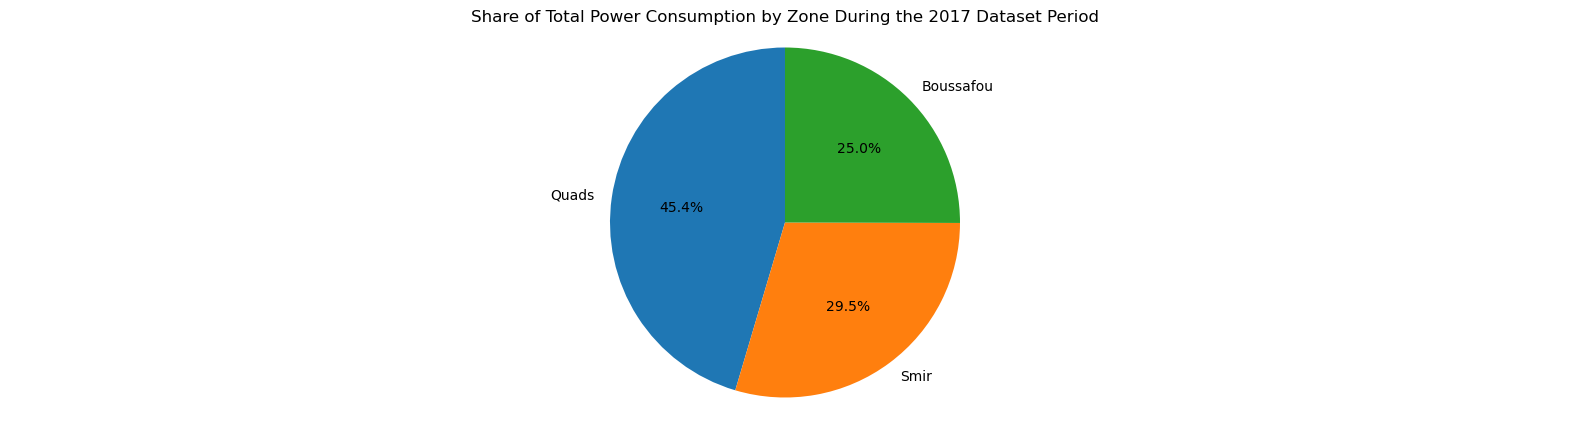

In [67]:
# Create a pie chart showing each zone's share of total consumption
plt.pie(
    zone_demand_summary["total_consumption"],
    labels=zone_demand_summary.index,
    autopct="%1.1f%%",
    startangle=90
)

# Add a chart title
plt.title("Share of Total Power Consumption by Zone During the 2017 Dataset Period")

# Keep the pie chart circular
plt.axis("equal")

# Display the chart
plt.show()

Quads accounted for the largest share of total power consumption during the dataset period, contributing 45.4% of combined demand. Smir contributed 29.5%, while Boussafou accounted for 25.0%. This indicates that Quads was the dominant electricity-consuming zone over the study period.

In [68]:
# Calculate variation measures for each zone
zone_variation_summary = pd.DataFrame({
    "average_consumption": df[zone_columns].mean(),
    "standard_deviation": df[zone_columns].std()
})

# Calculate the coefficient of variation as a percentage
zone_variation_summary["coefficient_of_variation_%"] = (
    zone_variation_summary["standard_deviation"]
    / zone_variation_summary["average_consumption"]
    * 100
)

# Rename the rows using readable zone names
zone_variation_summary = zone_variation_summary.rename(index={
    "quads_power_consumption": "Quads",
    "smir_power_consumption": "Smir",
    "boussafou_power_consumption": "Boussafou"
})

# Sort by relative variability
zone_variation_summary = zone_variation_summary.sort_values(
    by="coefficient_of_variation_%",
    ascending=False
)

zone_variation_summary

,average_consumption,standard_deviation,coefficient_of_variation_%
Boussafou,"17,835.41","6,622.17",37.13
Smir,"21,042.51","5,201.47",24.72
Quads,"32,344.97","7,130.56",22.05


Boussafou showed the greatest overall variation in electricity demand relative to its average consumption, with a coefficient of variation of 37.13%. Smir followed at 24.72%, while Quads was the most stable relative to its average demand at 22.05%. Although Quads had the highest standard deviation in absolute terms, Boussafou experienced the largest proportional fluctuations.

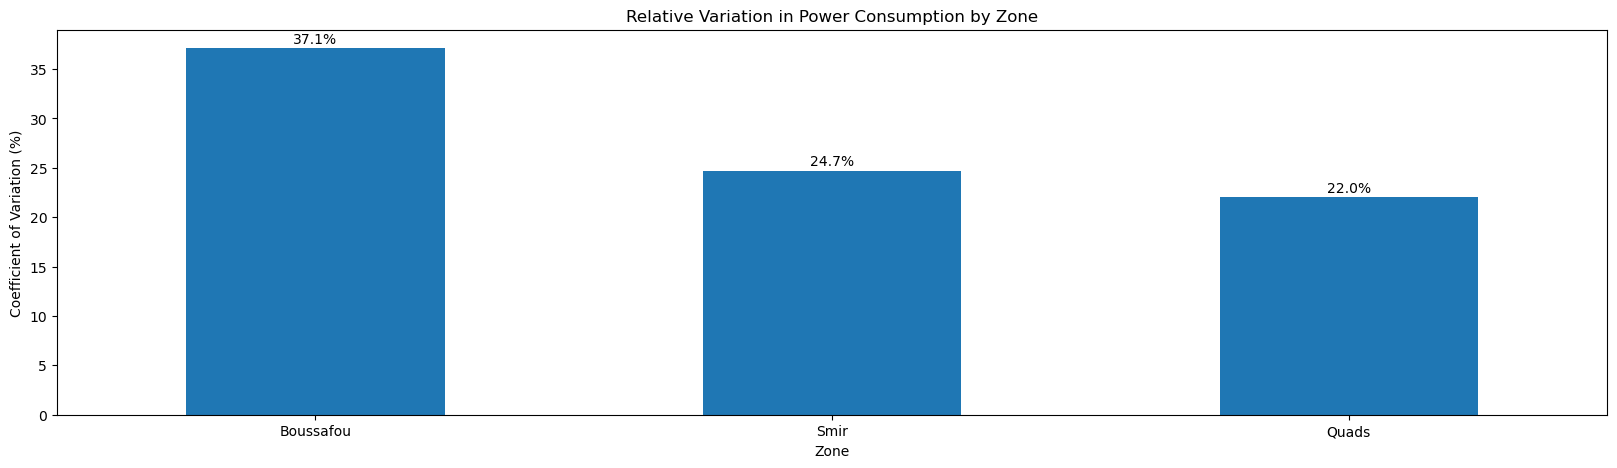

In [69]:
# Create a bar chart of relative demand variation by zone
zone_variation_summary["coefficient_of_variation_%"].plot(
    kind="bar"
)

# Add a clear title and axis labels
plt.title("Relative Variation in Power Consumption by Zone")
plt.xlabel("Zone")
plt.ylabel("Coefficient of Variation (%)")

# Rotate the zone labels for readability
plt.xticks(rotation=0)

# Add percentage labels above each bar
for index, value in enumerate(
    zone_variation_summary["coefficient_of_variation_%"]
):
    plt.text(
        index,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

# Display the chart
plt.show()

Coefficient of Variation

The coefficient of variation, often shortened to CV, measures how much a variable changes relative to its average value.

It is useful here because the three zones have different average consumption levels. Standard deviation alone tells us the size of the fluctuations, but the coefficient of variation tells us how large those fluctuations are compared with each zone’s typical demand.

The formula is:

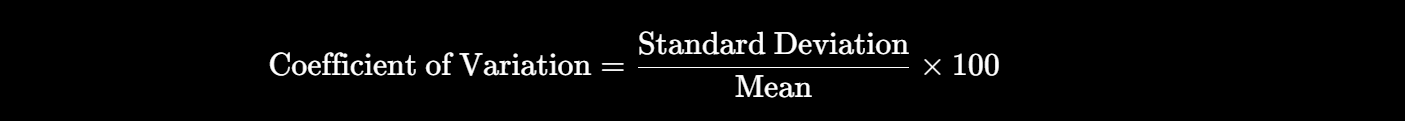

># 3. Hourly Demand Patterns

In [70]:
# Create an hour column from the datetime column
df["hour"] = df["datetime"].dt.hour

# Preview the datetime and new hour column
df[["datetime", "hour"]].head()

,datetime,hour
0,2017-01-01 00:00:00,0
1,2017-01-01 00:10:00,0
2,2017-01-01 00:20:00,0
3,2017-01-01 00:30:00,0
4,2017-01-01 00:40:00,0


In [71]:
# Calculate average power consumption by hour for each zone
hourly_demand = (
    df.groupby("hour")[
        [
            "quads_power_consumption",
            "smir_power_consumption",
            "boussafou_power_consumption",
            "total_power_consumption"
        ]
    ]
    .mean()
    .reset_index()
)

# Preview the hourly summary
hourly_demand.head()

,hour,quads_power_consumption,smir_power_consumption,boussafou_power_consumption,total_power_consumption
0,0,"30,217.24","19,692.07","18,657.22","68,566.53"
1,1,"27,565.53","17,765.08","16,970.80","62,301.42"
2,2,"26,292.69","16,730.16","15,981.10","59,003.94"
3,3,"25,338.12","16,052.59","15,238.61","56,629.31"
4,4,"24,633.58","15,624.08","14,671.04","54,928.70"


In [72]:
# Find the hour with the highest average total consumption
highest_hour = hourly_demand.loc[
    hourly_demand["total_power_consumption"].idxmax()
]

# Find the hour with the lowest average total consumption
lowest_hour = hourly_demand.loc[
    hourly_demand["total_power_consumption"].idxmin()
]

# Display both results
highest_hour, lowest_hour

(hour                              20.00
 quads_power_consumption       43,822.59
 smir_power_consumption        28,186.91
 boussafou_power_consumption   26,027.61
 total_power_consumption       98,037.11
 Name: 20, dtype: float64,
 hour                               6.00
 quads_power_consumption       23,203.60
 smir_power_consumption        14,934.70
 boussafou_power_consumption   12,051.60
 total_power_consumption       50,189.90
 Name: 6, dtype: float64)

Electricity demand followed a clear daily cycle. Average total consumption was lowest at 6:00 AM, before rising through the day and reaching its highest level at 8:00 PM. This indicates a strong evening peak, likely associated with increased residential and commercial activity.

In [73]:
"""Let us check whether all three zones peak and bottom out at the same hour:"""
# Create an empty list to store the hourly peak and minimum results
zone_hourly_extremes = []

# Check each zone separately
for column in zone_columns:
    """Select the column
        → identify the index of its highest or lowest value
        → use .loc[] to retrieve the entire corresponding row"""
    
    # Find the hour with the highest average consumption
    peak_row = hourly_demand.loc[
        hourly_demand[column].idxmax() #.idxmax() returns the index label of the first maximum value in a Series.
    ]
    
    # Find the hour with the lowest average consumption
    minimum_row = hourly_demand.loc[
        hourly_demand[column].idxmin() #.idxmin() returns the index label of the first minimum value in a Series.
    ]
    
    # Store the results
    zone_hourly_extremes.append({
        "zone": column,
        "peak_hour": int(peak_row["hour"]),
        "peak_average_consumption": peak_row[column],
        "minimum_hour": int(minimum_row["hour"]),
        "minimum_average_consumption": minimum_row[column]
    })

# Convert the results into a dataframe
zone_hourly_extremes = pd.DataFrame(zone_hourly_extremes)

# Replace technical names with readable zone names
zone_hourly_extremes["zone"] = zone_hourly_extremes["zone"].replace({
    "quads_power_consumption": "Quads",
    "smir_power_consumption": "Smir",
    "boussafou_power_consumption": "Boussafou"
})

zone_hourly_extremes

,zone,peak_hour,peak_average_consumption,minimum_hour,minimum_average_consumption
0,Quads,20,"43,822.59",6,"23,203.60"
1,Smir,20,"28,186.91",6,"14,934.70"
2,Boussafou,20,"26,027.61",7,"11,667.86"


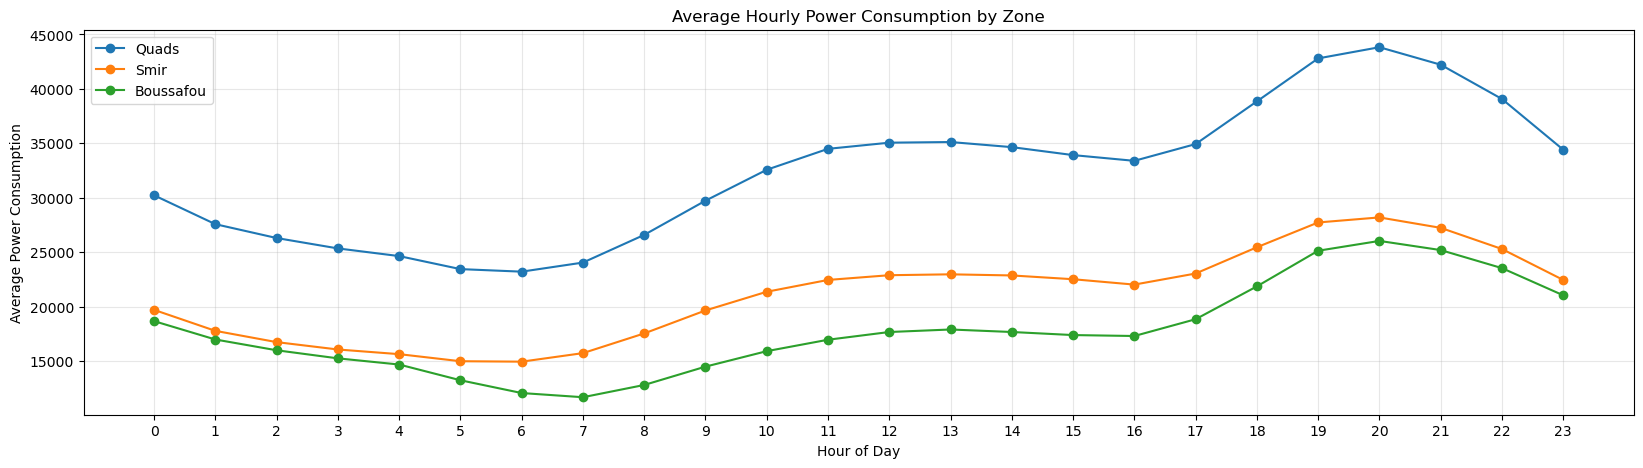

In [74]:
# Plot hourly average consumption for each zone
plt.plot(
    hourly_demand["hour"],
    hourly_demand["quads_power_consumption"],
    marker="o",
    label="Quads"
)

plt.plot(
    hourly_demand["hour"],
    hourly_demand["smir_power_consumption"],
    marker="o",
    label="Smir"
)

plt.plot(
    hourly_demand["hour"],
    hourly_demand["boussafou_power_consumption"],
    marker="o",
    label="Boussafou"
)

# Add title and axis labels
plt.title("Average Hourly Power Consumption by Zone")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Consumption")

# Show every hour from 0 to 23
plt.xticks(range(24))

# Add gridlines and legend
plt.grid(alpha=0.3)
plt.legend()

# Display the chart
plt.show()

All three zones followed a similar daily electricity-demand pattern. Consumption declined overnight, reached its lowest level between 6:00 AM and 7:00 AM, and then increased throughout the morning. Demand remained relatively stable during the middle of the day before rising sharply in the evening. Quads, Smir and Boussafou all reached their highest average consumption at 8:00 PM (20:00 hours), confirming a common city-wide evening peak.

># 4. Daily and Weekly Patterns

In [75]:
# Create a date column without the time portion
df["date"] = df["datetime"].dt.date

# Create the day name
df["day_name"] = df["datetime"].dt.day_name()

# Identify whether each observation occurred on a weekend
df["is_weekend"] = df["datetime"].dt.dayofweek >= 5

# Preview the new columns
df[["datetime", "date", "day_name", "is_weekend"]].head()

,datetime,date,day_name,is_weekend
0,2017-01-01 00:00:00,2017-01-01,Sunday,True
1,2017-01-01 00:10:00,2017-01-01,Sunday,True
2,2017-01-01 00:20:00,2017-01-01,Sunday,True
3,2017-01-01 00:30:00,2017-01-01,Sunday,True
4,2017-01-01 00:40:00,2017-01-01,Sunday,True


In [76]:
# Convert the Boolean weekend indicator into readable labels
df["day_type"] = np.where(
    df["is_weekend"],
    "Weekend",
    "Weekday"
)

# Preview the result
df[["datetime", "day_name", "is_weekend", "day_type"]].head()

,datetime,day_name,is_weekend,day_type
0,2017-01-01 00:00:00,Sunday,True,Weekend
1,2017-01-01 00:10:00,Sunday,True,Weekend
2,2017-01-01 00:20:00,Sunday,True,Weekend
3,2017-01-01 00:30:00,Sunday,True,Weekend
4,2017-01-01 00:40:00,Sunday,True,Weekend


In [77]:
# Define the correct chronological order for the days of the week
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate average power consumption by day of the week
weekly_demand = (
    df.groupby("day_name")[
        [
            "quads_power_consumption",
            "smir_power_consumption",
            "boussafou_power_consumption",
            "total_power_consumption"
        ]
    ]
    .mean()
    .reindex(day_order)
    .reset_index()
)

# Display the weekly summary
weekly_demand

,day_name,quads_power_consumption,smir_power_consumption,boussafou_power_consumption,total_power_consumption
0,Monday,"32,615.41","21,280.07","17,809.08","71,704.56"
1,Tuesday,"32,713.03","21,518.60","17,831.69","72,063.32"
2,Wednesday,"32,871.76","21,627.36","17,851.40","72,350.52"
3,Thursday,"32,842.48","21,845.16","17,843.69","72,531.34"
4,Friday,"32,339.00","21,461.04","17,545.97","71,346.01"
5,Saturday,"32,253.03","20,585.96","18,011.19","70,850.18"
6,Sunday,"30,780.08","18,979.38","17,954.83","67,714.28"


Average total power consumption was highest on Thursday and lowest on Sunday. Demand remained relatively consistent from Monday through Friday, before declining over the weekend. Sunday showed the clearest reduction in city-wide electricity consumption.

In [78]:
# Calculate average power consumption for weekdays and weekends
day_type_demand = (
    df.groupby("day_type")[
        [
            "quads_power_consumption",
            "smir_power_consumption",
            "boussafou_power_consumption",
            "total_power_consumption"
        ]
    ]
    .mean()
    .reindex(["Weekday", "Weekend"])
)

# Display the results
day_type_demand

,quads_power_consumption,smir_power_consumption,boussafou_power_consumption,total_power_consumption
day_type,,,,
Weekday,"32,676.34","21,546.45","17,776.37","71,999.15"
Weekend,"31,516.56","19,782.67","17,983.01","69,282.23"


In [79]:
# Calculate how much lower weekend demand is than weekday demand
weekend_difference_pct = (
    (
        day_type_demand.loc["Weekday", "total_power_consumption"]
        - day_type_demand.loc["Weekend", "total_power_consumption"]
    )
    / day_type_demand.loc["Weekday", "total_power_consumption"]
    * 100
)

weekend_difference_pct

3.773540007975772

Average total power consumption was approximately 3.77% lower on weekends than on weekdays. The reduction was driven mainly by Quads and Smir, while Boussafou recorded slightly higher average weekend demand. This suggests that the effect of weekends differs across the three zones rather than producing a uniform city-wide decline.

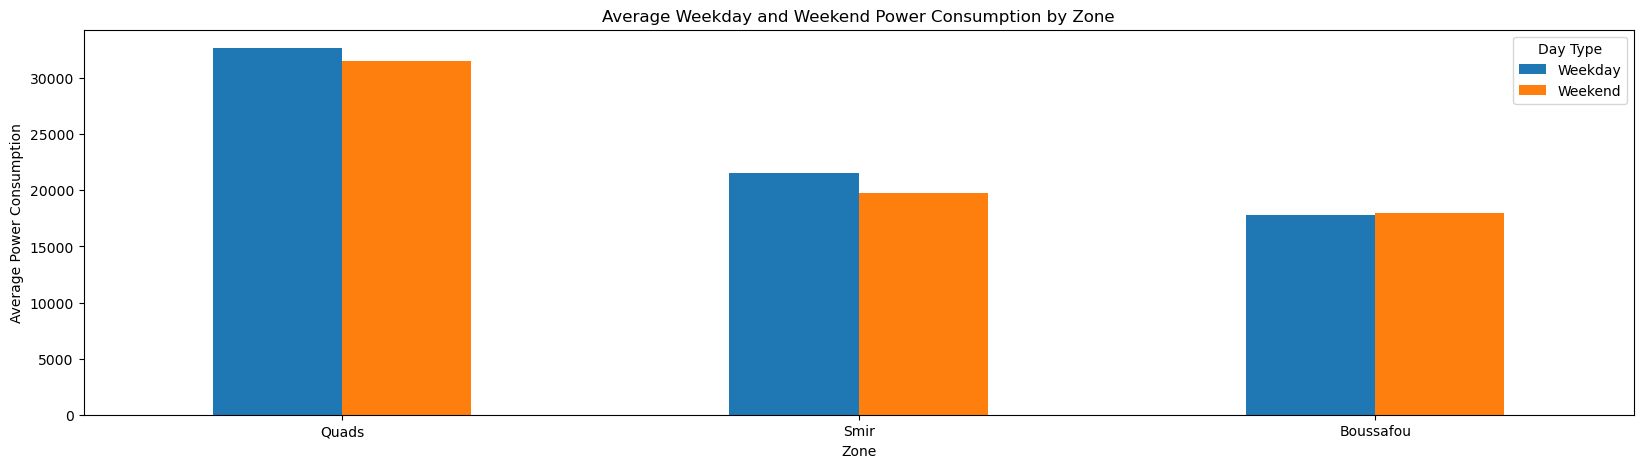

In [80]:
"""Does the weekday-versus-weekend pattern differ across the three zones?"""

# Transpose the table so the zones become the x-axis categories
day_type_chart = day_type_demand[
    [
        "quads_power_consumption",
        "smir_power_consumption",
        "boussafou_power_consumption"
    ]
].T

# Rename the technical zone labels
day_type_chart.index = [
    "Quads",
    "Smir",
    "Boussafou"
]

# Create a grouped bar chart
day_type_chart.plot(
    kind="bar"
)

# Add a clear title and axis labels
plt.title("Average Weekday and Weekend Power Consumption by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Power Consumption")

# Keep the zone labels horizontal
plt.xticks(rotation=0)

# Add the legend title
plt.legend(title="Day Type")

# Display the chart
plt.show()

Weekday and weekend demand patterns differed across the three zones. 

<li>Quads and Smir recorded lower average consumption on weekends, with Smir showing the largest reduction. 
<li>In contrast, Boussafou recorded slightly higher average weekend consumption. 

This suggests that the weekend effect is not uniform across Tetouan and may reflect differences in residential, commercial or industrial activity among the zones.

># 5. Monthly and Seasonal Patterns

In [81]:
# Create the month number
df["month"] = df["datetime"].dt.month

# Create the full month name
df["month_name"] = df["datetime"].dt.month_name()

# Preview the new columns
df[["datetime", "month", "month_name"]].head()

,datetime,month,month_name
0,2017-01-01 00:00:00,1,January
1,2017-01-01 00:10:00,1,January
2,2017-01-01 00:20:00,1,January
3,2017-01-01 00:30:00,1,January
4,2017-01-01 00:40:00,1,January


In [82]:
"""For this project, we are using:
        Winter: December–February
        Spring: March–May
        Summer: June–August
        Autumn: September–November"""

# Create a function to assign each month to a season
def assign_season(month):
    
    # December, January and February
    if month in [12, 1, 2]:
        return "Winter"
    
    # March, April and May
    elif month in [3, 4, 5]:
        return "Spring"
    
    # June, July and August
    elif month in [6, 7, 8]:
        return "Summer"
    
    # September, October and November
    else:
        return "Autumn"


# Apply the function to the month column
df["season"] = df["month"].apply(assign_season)

# Preview the result
df[["datetime", "month_name", "season"]].head()

,datetime,month_name,season
0,2017-01-01 00:00:00,January,Winter
1,2017-01-01 00:10:00,January,Winter
2,2017-01-01 00:20:00,January,Winter
3,2017-01-01 00:30:00,January,Winter
4,2017-01-01 00:40:00,January,Winter


In [83]:
# Define the correct chronological order for the months
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

# Calculate average power consumption by month
monthly_demand = (
    df.groupby("month_name")[
        [
            "quads_power_consumption",
            "smir_power_consumption",
            "boussafou_power_consumption",
            "total_power_consumption"
        ]
    ]
    .mean()
    .reindex(month_order)
    .reset_index()
)

# Display the monthly summary
monthly_demand

,month_name,quads_power_consumption,smir_power_consumption,boussafou_power_consumption,total_power_consumption
0,January,"31,032.49","19,394.44","17,746.10","68,173.03"
1,February,"30,985.75","18,787.79","17,335.00","67,108.55"
2,March,"31,155.17","18,457.94","16,947.69","66,560.79"
3,April,"31,169.77","17,633.97","18,593.17","67,396.90"
4,May,"32,396.01","19,977.29","17,621.10","69,994.40"
5,June,"34,605.54","20,670.93","20,430.94","75,707.41"
6,July,"35,831.55","24,147.89","28,194.11","88,173.55"
7,August,"36,435.19","24,656.22","24,648.89","85,740.30"
8,September,"33,396.68","20,180.43","14,922.80","68,499.91"
9,October,"32,827.66","21,468.99","13,264.10","67,560.75"


The monthly pattern is very clear.

<li>Highest average total consumption: July — 88,173.55
<li>Second highest: August — 85,740.30
<li>Lowest average total consumption: December — 63,750.83

Average total power consumption increased sharply from late spring into summer, reaching its highest level in July. 

Demand remained high in August before declining substantially in September. 

The lowest average total consumption occurred in December. This indicates a pronounced seasonal pattern, with the strongest demand concentrated in the summer months.

There is also an important zone-level difference:

<li>Quads peaks in August
<li>Smir peaks in August
<li>Boussafou peaks in July

In [84]:
# Define the correct seasonal order
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

# Calculate average power consumption by season
seasonal_demand = (
    df.groupby("season")[
        [
            "quads_power_consumption",
            "smir_power_consumption",
            "boussafou_power_consumption",
            "total_power_consumption"
        ]
    ]
    .mean()
    .reindex(season_order)
    .reset_index()
)

# Display the seasonal summary
seasonal_demand

,season,quads_power_consumption,smir_power_consumption,boussafou_power_consumption,total_power_consumption
0,Winter,"30,340.83","20,648.78","15,357.90","66,347.51"
1,Spring,"31,578.04","18,701.21","17,711.17","67,990.41"
2,Summer,"35,635.17","23,185.38","24,468.06","83,288.61"
3,Autumn,"31,754.08","21,628.19","13,678.53","67,060.80"


The seasonal pattern confirms what we saw in the monthly table:

<li>Summer has by far the highest average total consumption: 83,288.61
<li>Spring follows at 67,990.41
<li>Autumn averages 67,060.80
<li>Winter is lowest at 66,347.51

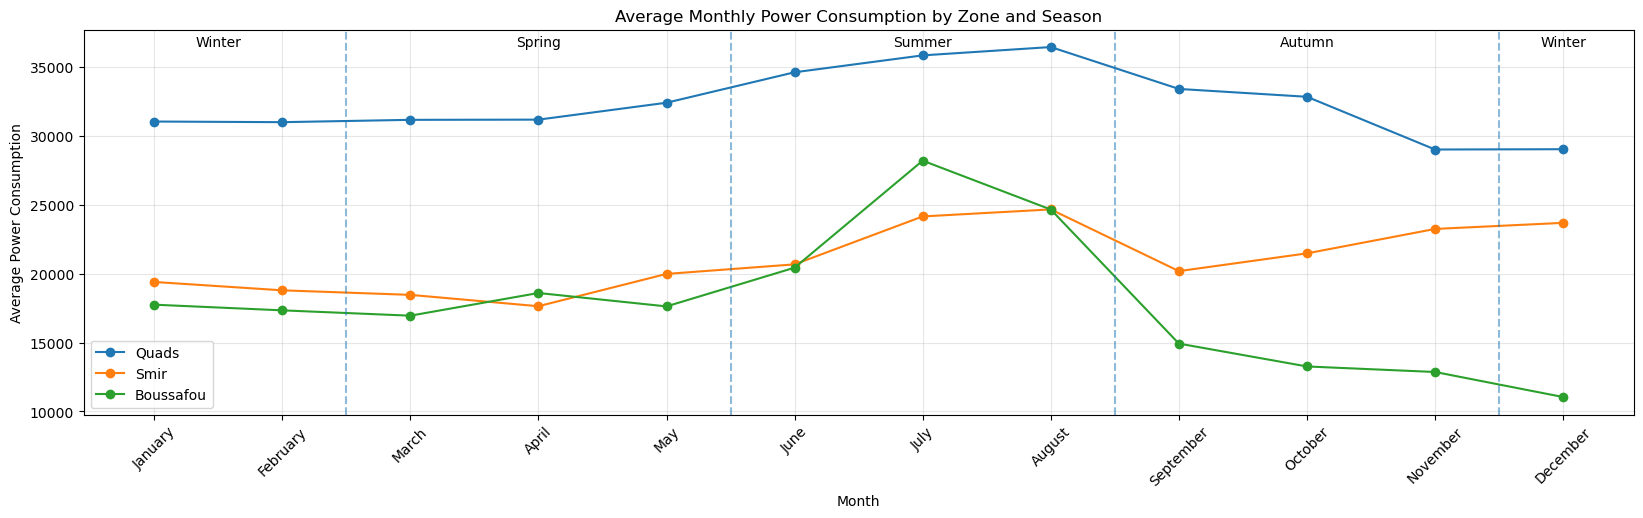

In [85]:
# Plot average monthly consumption for each zone
plt.plot(
    monthly_demand["month_name"],
    monthly_demand["quads_power_consumption"],
    marker="o",
    label="Quads"
)

plt.plot(
    monthly_demand["month_name"],
    monthly_demand["smir_power_consumption"],
    marker="o",
    label="Smir"
)

plt.plot(
    monthly_demand["month_name"],
    monthly_demand["boussafou_power_consumption"],
    marker="o",
    label="Boussafou"
)

# Add vertical dashed lines where each new season begins
plt.axvline(x=1.5, linestyle="--", alpha=0.5)   # Spring starts after February
plt.axvline(x=4.5, linestyle="--", alpha=0.5)   # Summer starts after May
plt.axvline(x=7.5, linestyle="--", alpha=0.5)   # Autumn starts after August
plt.axvline(x=10.5, linestyle="--", alpha=0.5)  # Winter starts after November

# Add season labels near the top of the chart
plt.text(0.5, 36500, "Winter", ha="center")
plt.text(3.0, 36500, "Spring", ha="center")
plt.text(6.0, 36500, "Summer", ha="center")
plt.text(9.0, 36500, "Autumn", ha="center")
plt.text(11.0, 36500, "Winter", ha="center")

# Add title and axis labels
plt.title("Average Monthly Power Consumption by Zone and Season")
plt.xlabel("Month")
plt.ylabel("Average Power Consumption")

# Rotate month labels for readability
plt.xticks(rotation=45)

# Add gridlines and legend
plt.grid(alpha=0.3)
plt.legend()

# Display the chart
plt.show()

The chart also makes the main findings easier to see:

<li>Summer demand rises sharply across all zones;
<li>Boussafou has the most dramatic summer spike;
<li>Autumn shows a strong decline in Boussafou;
<li>Quads remains the highest-consuming zone throughout the year;
<li>Smir rises again toward winter while Boussafou continues falling.

># 6. Weather and Electricity Consumption

In [86]:
# Store the weather columns in a list
weather_columns = [
    "temperature",
    "humidity",
    "wind_speed",
    "general_diffuse_flows",
    "diffuse_flows"
]

# Store the electricity-consumption columns in a list
consumption_columns = [
    "quads_power_consumption",
    "smir_power_consumption",
    "boussafou_power_consumption",
    "total_power_consumption"
]

In [87]:
# Calculate correlations between weather variables and electricity-consumption variables
"""The complete correlation matrix would compare every variable with every other variable. We only need:
        weather variables as the rows;
        consumption variables as the columns."""
weather_consumption_corr = (
    df[weather_columns + consumption_columns]
    .corr()
    .loc[weather_columns, consumption_columns])
    



# Display the correlation table
weather_consumption_corr

,quads_power_consumption,smir_power_consumption,boussafou_power_consumption,total_power_consumption
temperature,0.44,0.38,0.49,0.49
humidity,-0.29,-0.29,-0.23,-0.30
wind_speed,0.17,0.15,0.28,0.22
general_diffuse_flows,0.19,0.16,0.06,0.15
diffuse_flows,0.08,0.04,-0.04,0.03


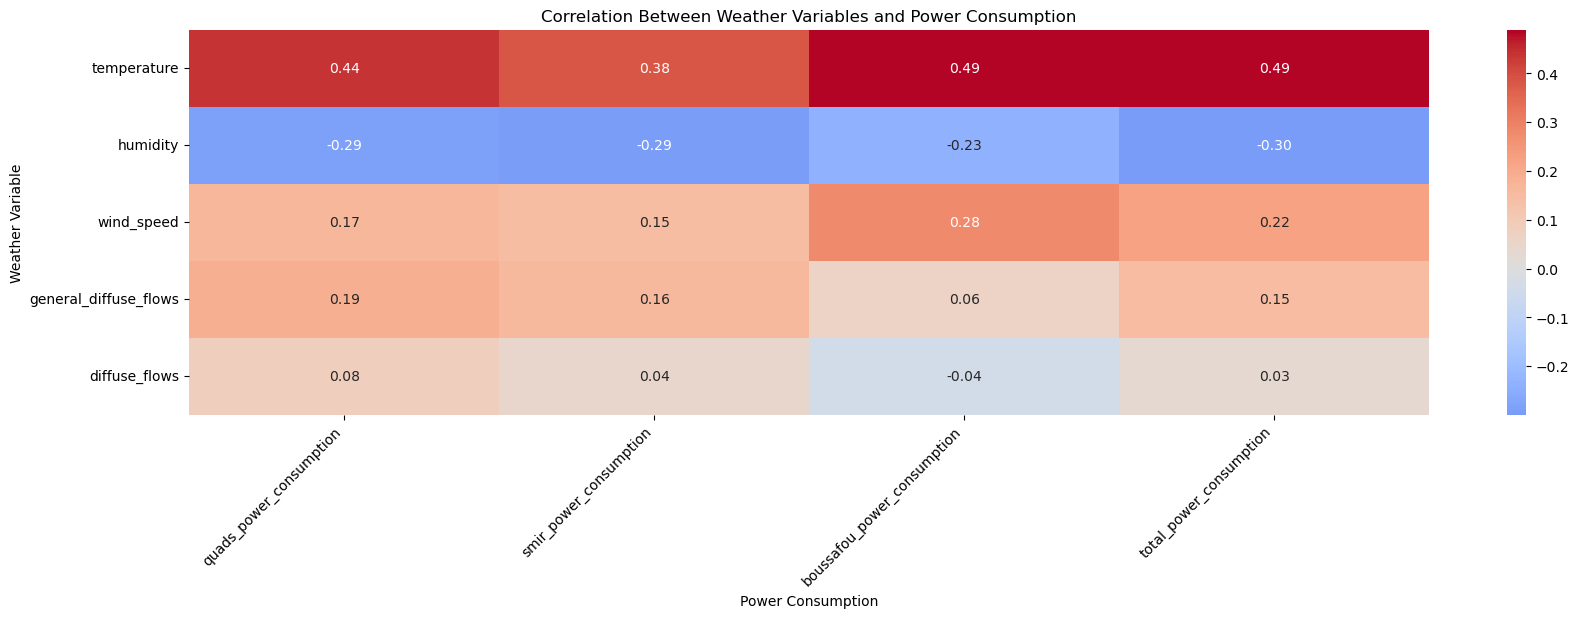

In [88]:
# Create a heatmap of weather-to-consumption correlations
sns.heatmap(
    weather_consumption_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

# Add a clear title and axis labels
plt.title("Correlation Between Weather Variables and Power Consumption")
plt.xlabel("Power Consumption")
plt.ylabel("Weather Variable")

# Rotate the x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Display the chart
plt.show()

The strongest finding is immediately visible:

<li>Temperature has the strongest positive relationship with demand.
<li>Humidity has a modest negative relationship.
<li>Wind speed has only a weak positive relationship.
<li>General diffuse flows have a weak relationship.
<li>Diffuse flows are essentially uncorrelated with consumption.

The correlation heatmap shows that temperature is the weather variable most strongly associated with electricity consumption across all three zones. The relationship is strongest for Boussafou and for total city consumption, both at 0.49. Humidity has a moderate negative relationship with demand, while wind speed and solar-radiation variables show weaker associations. Diffuse flows have almost no linear relationship with electricity consumption. Overall, temperature appears to be the most useful weather variable for explaining or predicting demand.

*Note-Correlation measures the strength of a linear relationship and does not prove causation. Weather variables may also interact with time of day and season, so their predictive value should be tested later in the forecasting section.

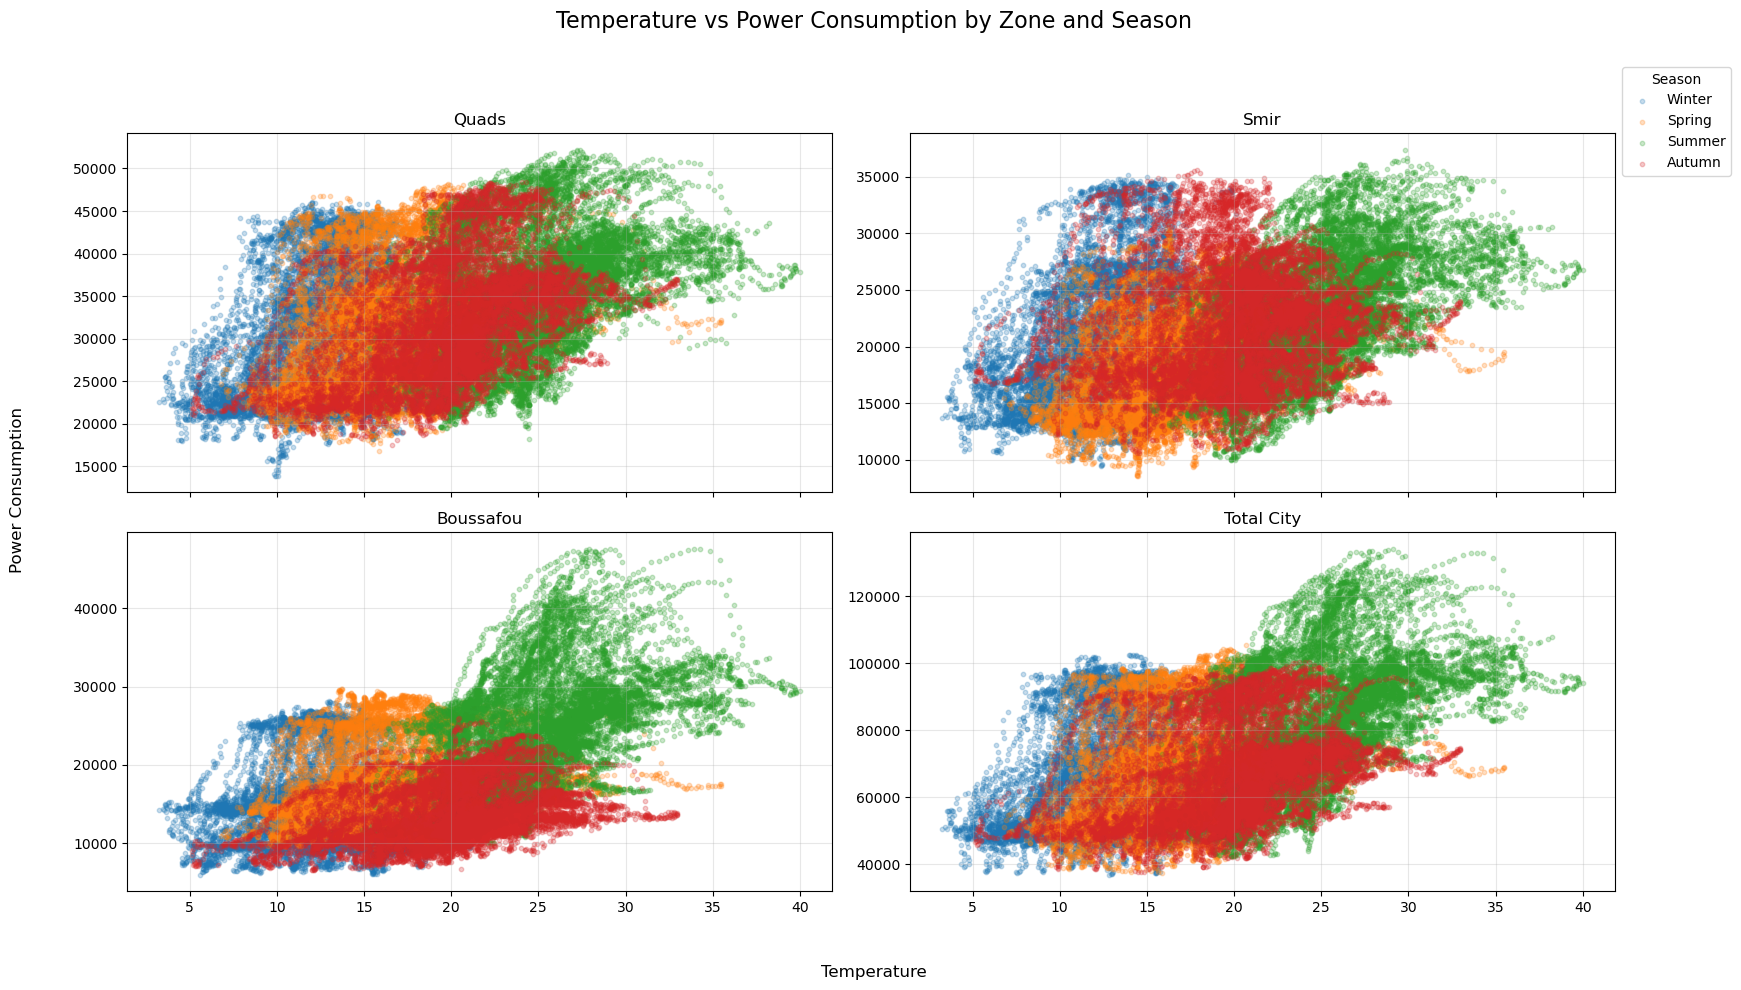

In [117]:
# Define the seasons in the order we want them displayed
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

# Define the four consumption measures to plot
plot_columns = {
    "Quads": "quads_power_consumption",
    "Smir": "smir_power_consumption",
    "Boussafou": "boussafou_power_consumption",
    "Total City": "total_power_consumption"
}

# Create a 2 x 2 grid with a shared x-axis only
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 10),
    sharex=True,
    sharey=False
)

# Flatten the 2 x 2 array so we can loop through each chart
axes = axes.flatten()

# Loop through each zone or consumption measure
for axis, (title, consumption_column) in zip(
    axes,
    plot_columns.items()
):

    # Plot each season separately so it appears in the legend
    for season_name in season_order:

        # Filter the dataframe for the current season
        season_data = df[df["season"] == season_name]

        # Plot temperature against the selected consumption column
        axis.scatter(
            season_data["temperature"],
            season_data[consumption_column],
            label=season_name,
            alpha=0.25,
            s=10
        )

    # Add an individual title to each panel
    axis.set_title(title)

    # Add light gridlines
    axis.grid(alpha=0.3)

# Add one overall title for the entire figure
fig.suptitle(
    "Temperature vs Power Consumption by Zone and Season",
    fontsize=16
)

# Add shared axis labels for the entire figure
fig.supxlabel("Temperature")
fig.supylabel("Power Consumption")

# Create one shared legend for all four panels
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Season",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.93)
)

# Adjust spacing so titles and labels do not overlap
plt.tight_layout(
    rect=[0.03, 0.03, 0.92, 0.93]
)

# Display the chart
plt.show()

The 2×2 scatter-plot grid shows that temperature is positively related to electricity consumption in all three zones, but the strength and shape of the relationship differ by location. Boussafou displays the clearest seasonal separation, with summer observations forming a distinct high-temperature, high-consumption cluster. Quads and Smir show greater seasonal overlap, indicating that temperature alone explains less of their demand variation. The total-city panel confirms that the highest combined consumption generally occurs during warmer summer conditions.

># 7. Peak-Demand Analysis

In [89]:
"""Begin with the single highest reading for each zone."""

# Create an empty list to store the peak-demand results
zone_peak_summary = []

# Check each zone separately
for column in zone_columns:
    
    # Find the index of the highest consumption reading
    peak_index = df[column].idxmax()
    
    # Retrieve the complete row containing that peak
    peak_row = df.loc[peak_index]
    
    # Store the relevant information
    zone_peak_summary.append({
        "zone": column,
        "peak_datetime": peak_row["datetime"],
        "peak_consumption": peak_row[column],
        "temperature": peak_row["temperature"],
        "humidity": peak_row["humidity"],
        "wind_speed": peak_row["wind_speed"],
        "general_diffuse_flows": peak_row["general_diffuse_flows"],
        "diffuse_flows": peak_row["diffuse_flows"]
    })

# Convert the results into a dataframe
zone_peak_summary = pd.DataFrame(zone_peak_summary)

# Replace technical column names with readable zone names
zone_peak_summary["zone"] = zone_peak_summary["zone"].replace({
    "quads_power_consumption": "Quads",
    "smir_power_consumption": "Smir",
    "boussafou_power_consumption": "Boussafou"
})

# Display the peak-demand summary
zone_peak_summary

,zone,peak_datetime,peak_consumption,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows
0,Quads,2017-08-07 20:20:00,"52,204.40",27.24,78.00,4.90,1.44,1.16
1,Smir,2017-07-24 19:40:00,"37,408.86",29.79,35.68,4.91,81.20,90.00
2,Boussafou,2017-07-24 20:10:00,"47,598.33",29.13,33.01,4.91,16.84,15.38


The individual zone peaks are concentrated in late July and early August, and all occurred in the evening:

<li>Quads: 7 August at 8:20 PM
<li>Smir: 24 July at 7:40 PM
<li>Boussafou: 24 July at 8:10 PM

The highest recorded demand in all three zones occurred during summer evenings. Quads reached its maximum on 7 August at 8:20 PM, while Smir and Boussafou both peaked on 24 July within the same 30-minute period. This indicates that major demand peaks were concentrated during hot summer evenings and may sometimes affect multiple zones simultaneously.

In [90]:
"""Now we should examine the top 10 total city-demand observations, because that gives a stronger picture than relying on only one maximum per zone:"""

# Select the 10 highest total-demand observations
top_10_system_peaks = (
    df.nlargest(
        10,
        "total_power_consumption"
    )[
        [
            "datetime",
            "total_power_consumption",
            "quads_power_consumption",
            "smir_power_consumption",
            "boussafou_power_consumption",
            "temperature",
            "humidity",
            "wind_speed",
            "general_diffuse_flows",
            "diffuse_flows"
        ]
    ]
    .sort_values(
        by="total_power_consumption",
        ascending=False
    )
)

# Display the results
top_10_system_peaks

,datetime,total_power_consumption,quads_power_consumption,smir_power_consumption,boussafou_power_consumption,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows
29497,2017-07-24 20:10:00,"134,208.15","51,540.20","35,069.62","47,598.33",29.13,33.01,4.91,16.84,15.38
29498,2017-07-24 20:20:00,"133,914.03","51,533.82","34,974.68","47,405.52",28.84,32.78,4.91,7.81,6.74
29929,2017-07-27 20:10:00,"133,675.19","51,208.50","34,868.35","47,598.33",27.93,61.19,4.91,24.64,19.90
29499,2017-07-24 20:30:00,"133,561.23","51,508.31","34,834.18","47,218.74",28.66,32.64,4.91,3.65,3.00
29930,2017-07-27 20:20:00,"133,408.14","51,297.81","34,674.68","47,435.65",27.74,61.55,4.91,11.01,9.14
29496,2017-07-24 20:00:00,"133,194.10","50,755.61","35,008.86","47,429.62",29.39,33.38,4.91,42.39,46.89
29642,2017-07-25 20:20:00,"133,111.38","51,029.90","34,826.58","47,254.90",26.98,57.99,4.91,7.51,6.45
29931,2017-07-27 20:30:00,"133,097.99","51,189.37","34,689.87","47,218.74",27.76,61.55,4.91,2.95,2.39
29786,2017-07-26 20:20:00,"132,893.84","50,800.27","34,651.90","47,441.67",33.58,29.78,4.91,8.30,7.15
29643,2017-07-25 20:30:00,"132,876.57","51,246.78","34,579.75","47,050.04",26.66,58.06,4.91,3.21,2.76


What the table shows:

<li>All 10 peaks occurred between 8:00 PM and 8:30 PM.
<li>All occurred during 24–27 July 2017.
<li>The highest total demand was 134,208.15 on 24 July at 8:10 PM.
<li>Boussafou contributed very heavily during these events, despite having the lowest annual average consumption.
<li>Temperatures during the peaks ranged from roughly 26.7°C to 33.6°C.
<li>Solar-radiation readings were low, which is expected because these were evening observations.

The highest system-wide demand events were tightly concentrated during a four-day period from 24 to 27 July 2017. Every top-10 observation occurred between 8:00 PM and 8:30 PM, confirming that the most severe peaks were summer-evening events rather than isolated daytime spikes. The repeated high readings across consecutive 10-minute intervals also indicate sustained peak periods rather than single anomalous observations.

In [91]:
"""Which zone contributes most during system-wide peaks?
Calculate each zone’s average percentage contribution across those top 10 observations:"""

# Create a copy so the original top-10 table remains unchanged
top_10_peak_contributions = top_10_system_peaks.copy()

# Calculate each zone's percentage contribution
# to total power consumption during each peak observation
top_10_peak_contributions["quads_percentage"] = (
    top_10_peak_contributions["quads_power_consumption"]
    / top_10_peak_contributions["total_power_consumption"]
    * 100
)

top_10_peak_contributions["smir_percentage"] = (
    top_10_peak_contributions["smir_power_consumption"]
    / top_10_peak_contributions["total_power_consumption"]
    * 100
)

top_10_peak_contributions["boussafou_percentage"] = (
    top_10_peak_contributions["boussafou_power_consumption"]
    / top_10_peak_contributions["total_power_consumption"]
    * 100
)

# Calculate the average contribution of each zone
peak_zone_contribution = pd.Series({
    "Quads": top_10_peak_contributions["quads_percentage"].mean(),
    "Smir": top_10_peak_contributions["smir_percentage"].mean(),
    "Boussafou": top_10_peak_contributions["boussafou_percentage"].mean()
}).sort_values(ascending=False)

# Display the average percentage contribution
peak_zone_contribution

Quads       38.39
Boussafou   35.51
Smir        26.10
dtype: float64

Quads remained the largest contributor during the top 10 system-wide demand peaks, accounting for an average of 38.39% of total consumption. However, Boussafou’s contribution increased sharply to 35.51%, compared with only about 25% across the full dataset. This indicates that Boussafou plays a disproportionately large role during extreme demand events and may require particular attention for peak-capacity planning.

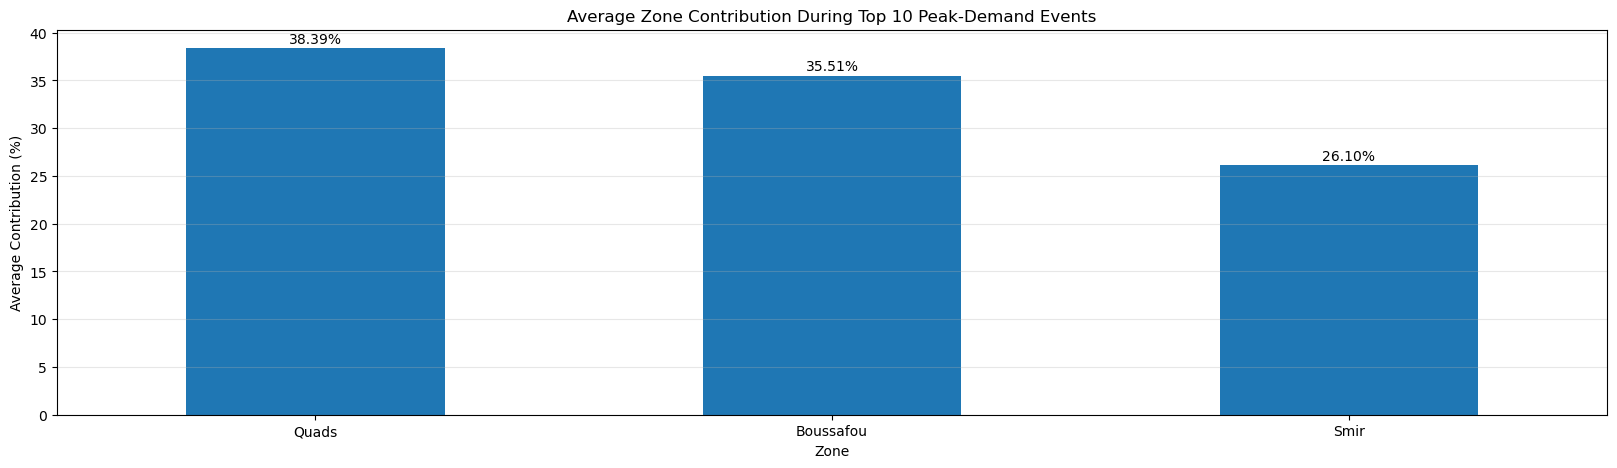

In [92]:
# Create a bar chart showing the average zone contribution
# during the top 10 system-wide peak-demand events
peak_zone_contribution.plot(
    kind="bar"
)

# Add a title and axis labels
plt.title("Average Zone Contribution During Top 10 Peak-Demand Events")
plt.xlabel("Zone")
plt.ylabel("Average Contribution (%)")

# Keep x-axis labels horizontal
plt.xticks(rotation=0)

# Add percentage labels above each bar
for index, value in enumerate(peak_zone_contribution):
    plt.text(
        index,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

# Add light gridlines
plt.grid(axis="y", alpha=0.3)

# Display the chart
plt.show()

During the top 10 system-wide peak-demand events, Quads contributed the largest average share at 38.39%. Boussafou followed closely at 35.51%, while Smir contributed 26.10%. Compared with its overall share of approximately 25%, Boussafou’s contribution rose substantially during extreme-demand periods, indicating that it plays a disproportionately important role during system-wide peaks.

># 8. Variability and Operational Risk

We already know: Boussafou has the greatest relative variability, with a coefficient of variation of 37.13%.

In [93]:
# Calculate the daily maximum and minimum consumption for each zone
daily_demand_range = (
    df.groupby("date")[zone_columns + ["total_power_consumption"]]
    .agg(["max", "min"])
)

# Preview the daily maximum and minimum values
daily_demand_range.head()

quads_power_consumption           smir_power_consumption            \
                               max       min                    max       min   
date                                                                            
2017-01-01               40,611.65 18,045.57              25,706.99 10,719.76   
2017-01-02               41,851.14 19,740.76              27,206.08 13,090.58   
2017-01-03               42,993.42 19,989.87              27,300.91 13,462.61   
2017-01-04               43,485.57 19,479.49              27,698.48 13,265.65   
2017-01-05               43,831.90 20,737.22              27,625.53 13,334.95   

           boussafou_power_consumption           total_power_consumption  \
                                   max       min                     max   
date                                                                       
2017-01-01                   26,573.49 10,455.90               92,742.23   
2017-01-02                   25,937.35 11,398.55               94,463.96   
2017-01-03                   26,238.07 11,624.10               95,972.69   
2017-01-04                   26,012.53 11,329.16               96,763.44   
2017-01-05                   25,943.13 11,381.20               97,093.47   

                      
                 min  
date                  
2017-01-01 39,239.46  
2017-01-02 46,472.36  
2017-01-03 47,182.44  
2017-01-04 46,678.03  
2017-01-05 47,783.26

In [94]:
"""calculate the difference between the daily maximum and minimum:"""

# Create a new dataframe for the daily demand ranges
daily_range_summary = pd.DataFrame({
    "quads_daily_range": (
        daily_demand_range[("quads_power_consumption", "max")]
        - daily_demand_range[("quads_power_consumption", "min")]
    ),

    "smir_daily_range": (
        daily_demand_range[("smir_power_consumption", "max")]
        - daily_demand_range[("smir_power_consumption", "min")]
    ),

    "boussafou_daily_range": (
        daily_demand_range[("boussafou_power_consumption", "max")]
        - daily_demand_range[("boussafou_power_consumption", "min")]
    ),

    "total_daily_range": (
        daily_demand_range[("total_power_consumption", "max")]
        - daily_demand_range[("total_power_consumption", "min")]
    )
})

# Preview the calculated daily demand ranges
daily_range_summary.head()

,quads_daily_range,smir_daily_range,boussafou_daily_range,total_daily_range
date,,,,
2017-01-01,"22,566.08","14,987.23","16,117.59","53,502.77"
2017-01-02,"22,110.38","14,115.50","14,538.80","47,991.61"
2017-01-03,"23,003.54","13,838.30","14,613.98","48,790.25"
2017-01-04,"24,006.08","14,432.83","14,683.37","50,085.41"
2017-01-05,"23,094.68","14,290.58","14,561.93","49,310.22"


What the daily range means

The daily demand range is:

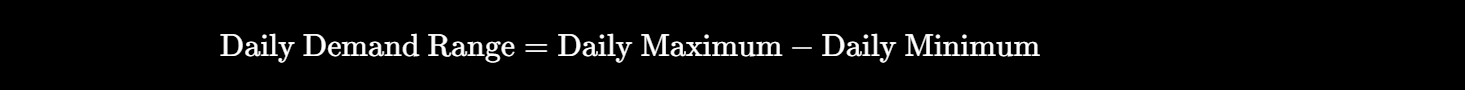

A larger range means consumption changed more dramatically during that day, which may create greater operational pressure for load balancing and capacity planning.

In [95]:
"""Now let us identify the largest daily swings."""

# Find the date with the largest total daily demand range
largest_total_swing = daily_range_summary.loc[
    daily_range_summary["total_daily_range"].idxmax()
]

# Display the date and values
largest_total_swing

quads_daily_range       26,975.68
smir_daily_range        20,996.20
boussafou_daily_range   28,727.70
total_daily_range       74,322.07
Name: 2017-07-24, dtype: float64

The largest city-wide daily swing occurred on 24 July 2017, when total demand changed by 74,322.07 between the day’s minimum and maximum.

In [96]:
"""Find the largest daily range for each zone:"""

# Create an empty list to store the largest daily swing for each zone
largest_zone_swings = []

# Check each daily-range column separately
for column in [
    "quads_daily_range",
    "smir_daily_range",
    "boussafou_daily_range"
]:
    
    # Find the date of the largest daily range
    largest_date = daily_range_summary[column].idxmax()
    
    # Store the result
    largest_zone_swings.append({
        "zone": column,
        "date": largest_date,
        "largest_daily_range": daily_range_summary.loc[
            largest_date,
            column
        ]
    })

# Convert the results into a dataframe
largest_zone_swings = pd.DataFrame(largest_zone_swings)

# Replace technical names with readable zone names
largest_zone_swings["zone"] = largest_zone_swings["zone"].replace({
    "quads_daily_range": "Quads",
    "smir_daily_range": "Smir",
    "boussafou_daily_range": "Boussafou"
})

largest_zone_swings

,zone,date,largest_daily_range
0,Quads,2017-01-15,"28,708.86"
1,Smir,2017-07-24,"20,996.20"
2,Boussafou,2017-07-23,"29,589.29"


The largest city-wide within-day demand swing occurred on 24 July 2017, when total consumption varied by 74,322.07 between the daily minimum and maximum. Smir also recorded its largest daily range on that date, while Boussafou’s largest range occurred one day earlier. These dates align closely with the late-July system-wide peak-demand period identified earlier. Quads differed from the other zones, recording its largest daily range in January.

This suggests that operational risk is not identical across the zones:

<li>Smir and Boussafou were most stressed during the late-July peak period.
<li>Quads experienced its largest daily fluctuation during winter.

In [97]:
# Calculate the average daily demand range for each zone
average_daily_range = pd.Series({
    "Quads": daily_range_summary["quads_daily_range"].mean(),
    "Smir": daily_range_summary["smir_daily_range"].mean(),
    "Boussafou": daily_range_summary["boussafou_daily_range"].mean()
}).sort_values(ascending=False)

average_daily_range

Quads       22,907.20
Boussafou   15,631.67
Smir        15,088.16
dtype: float64

Quads typically experiences the largest absolute within-day swing in electricity demand. However, Boussafou remains the most variable relative to its average consumption, based on the coefficient of variation calculated earlier.

Quads recorded the largest average daily demand range, indicating the greatest typical absolute change between daily minimum and maximum consumption. Boussafou had a smaller average daily range, but it remained the most variable zone relative to its average demand level. Therefore, Quads experiences the largest absolute daily swings, while Boussafou is less stable proportionally.

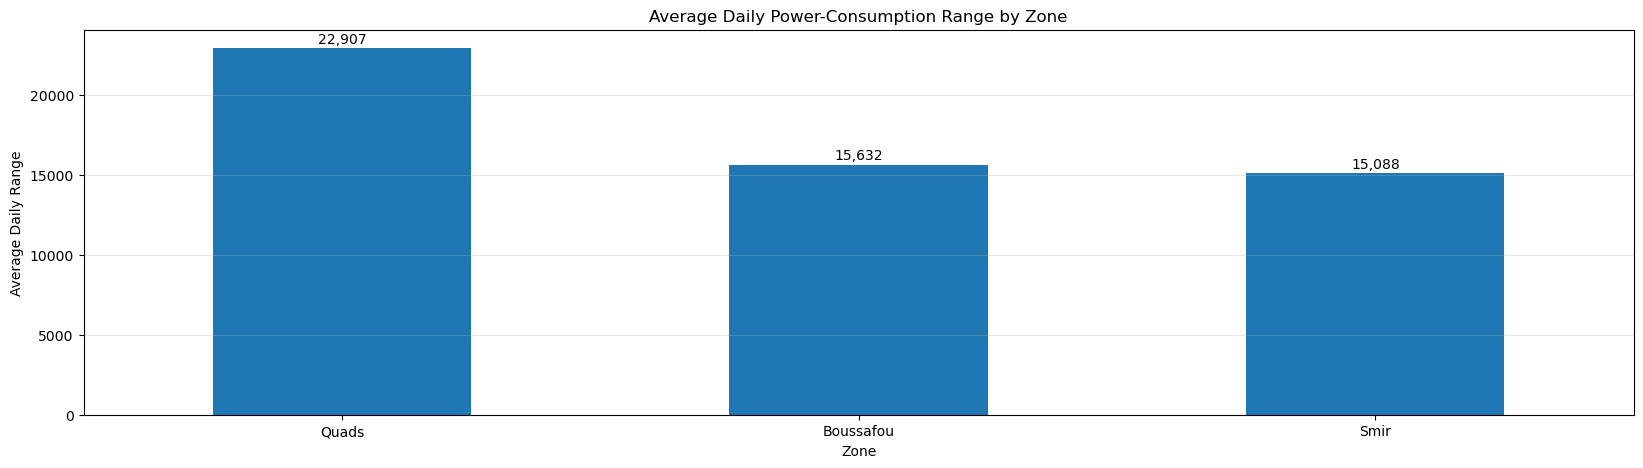

In [98]:
# Create a bar chart showing the average daily demand range by zone
average_daily_range.plot(
    kind="bar"
)

# Add a clear title and axis labels
plt.title("Average Daily Power-Consumption Range by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Daily Range")

# Keep zone labels horizontal
plt.xticks(rotation=0)

# Add value labels above each bar
for index, value in enumerate(average_daily_range):
    plt.text(
        index,
        value + 300,
        f"{value:,.0f}",
        ha="center"
    )

# Add light horizontal gridlines
plt.grid(axis="y", alpha=0.3)

# Display the chart
plt.show()

<li>Quads recorded the largest average daily peak-to-minimum range at approximately 22,907, indicating the greatest typical absolute change in demand within a day. 
<li>Boussafou and Smir had similar but lower average daily ranges. 
<li>However, Boussafou remains the most variable zone relative to its average consumption level, based on the coefficient of variation calculated earlier.

This gives us a strong operational takeaway:

Quads may require the most attention for managing large daily load swings, while Boussafou may be more difficult to predict proportionally because its demand fluctuates more relative to its usual level.

In [99]:
"""Because the data is recorded every 10 minutes:

6 readings = 1 hour
144 readings = 1 day

We’ll use a 24-hour rolling window and flag observations more than 3 rolling standard deviations from the rolling mean."""

# Create a 24-hour rolling mean
df["rolling_mean_24h"] = (
    df["total_power_consumption"]
    .rolling(window=144)
    .mean()
)

# Create a 24-hour rolling standard deviation
df["rolling_std_24h"] = (
    df["total_power_consumption"]
    .rolling(window=144)
    .std()
)

# Calculate the rolling upper and lower anomaly boundaries
df["rolling_upper_bound"] = (
    df["rolling_mean_24h"]
    + 3 * df["rolling_std_24h"]
)

df["rolling_lower_bound"] = (
    df["rolling_mean_24h"]
    - 3 * df["rolling_std_24h"]
)

# Flag observations outside the rolling boundaries
df["rolling_anomaly"] = (
    (df["total_power_consumption"] > df["rolling_upper_bound"])
    |
    (df["total_power_consumption"] < df["rolling_lower_bound"])
)

# Count the identified anomalies
df["rolling_anomaly"].value_counts()

rolling_anomaly
False    52416
Name: count, dtype: int64

Why use a rolling method?

A global mean compares every observation with the entire year. That may incorrectly flag normal summer peaks or winter lows.

A rolling method compares each reading with its recent 24-hour pattern, making it better suited to time-series data.

The first 143 rows will not have complete rolling statistics because a full 24-hour window is not yet available. They will not be marked as anomalies.

In [100]:
# Display observations identified as rolling anomalies
rolling_anomalies = df.loc[
    df["rolling_anomaly"],
    [
        "datetime",
        "total_power_consumption",
        "rolling_mean_24h",
        "rolling_upper_bound",
        "rolling_lower_bound",
        "temperature",
        "humidity"
    ]
]

rolling_anomalies

,datetime,total_power_consumption,rolling_mean_24h,rolling_upper_bound,rolling_lower_bound,temperature,humidity


No rolling anomalies were identified using a 24-hour rolling mean and a three-standard-deviation threshold. This suggests that even the most extreme consumption values were part of broader daily demand patterns rather than isolated data errors or unexpected one-off events.

One caution: a 3-standard-deviation threshold is fairly strict. It is possible that a 2-standard-deviation threshold would identify unusual—but still valid—events. For this project, I would keep the 3-standard-deviation result and avoid adding another anomaly method unless Section 8 specifically needs more depth

In [101]:
# Create a 24-hour rolling mean
df["rolling_mean_24h"] = (
    df["total_power_consumption"]
    .rolling(window=144)
    .mean()
)

# Create a 24-hour rolling standard deviation
df["rolling_std_24h"] = (
    df["total_power_consumption"]
    .rolling(window=144)
    .std()
)

# Calculate the rolling upper and lower anomaly boundaries
df["rolling_upper_bound"] = (
    df["rolling_mean_24h"]
    + 2 * df["rolling_std_24h"]
)

df["rolling_lower_bound"] = (
    df["rolling_mean_24h"]
    - 2 * df["rolling_std_24h"]
)

# Flag observations outside the rolling boundaries
df["rolling_anomaly"] = (
    (df["total_power_consumption"] > df["rolling_upper_bound"])
    |
    (df["total_power_consumption"] < df["rolling_lower_bound"])
)

# Count the identified anomalies
df["rolling_anomaly"].value_counts()

rolling_anomaly
False    51708
True       708
Name: count, dtype: int64

In [102]:
# Display observations identified as rolling anomalies
rolling_anomalies = df.loc[
    df["rolling_anomaly"],
    [
        "datetime",
        "total_power_consumption",
        "rolling_mean_24h",
        "rolling_upper_bound",
        "rolling_lower_bound",
        "temperature",
        "humidity"
    ]
]

rolling_anomalies

,datetime,total_power_consumption,rolling_mean_24h,rolling_upper_bound,rolling_lower_bound,temperature,humidity
9329,2017-03-06 18:50:00,"95,833.31","67,311.99","95,152.25","39,471.73",14.26,63.85
9330,2017-03-06 19:00:00,"95,955.86","67,366.65","95,401.40","39,331.90",14.17,64.05
9331,2017-03-06 19:10:00,"96,204.41","67,417.68","95,636.15","39,199.21",14.04,64.59
9332,2017-03-06 19:20:00,"96,245.67","67,466.80","95,861.89","39,071.72",13.92,65.15
10339,2017-03-13 19:10:00,"95,871.25","67,433.50","95,608.54","39,258.47",16.36,64.92
...,...,...,...,...,...,...,...
50653,2017-12-18 18:10:00,"90,719.33","63,610.79","90,401.02","36,820.57",15.48,77.20
50654,2017-12-18 18:20:00,"91,287.83","63,667.27","90,656.99","36,677.54",15.32,77.80
50655,2017-12-18 18:30:00,"90,991.81","63,717.37","90,883.67","36,551.07",15.17,78.40
51659,2017-12-25 17:50:00,"91,976.15","64,830.94","91,295.92","38,365.95",15.03,61.45


Using a 24-hour rolling window and a two-standard-deviation threshold, 708 observations were identified as unusually high or low relative to the preceding daily pattern. These observations represent approximately 1.35% of the dataset. Because no observations were flagged at the stricter three-standard-deviation threshold, the detected events are better interpreted as moderate deviations from normal daily behaviour rather than extreme anomalies or likely data errors.

For this project, I would keep both results:

<li>3 standard deviations: no extreme anomalies
<li>2 standard deviations: 708 moderate anomalies

We established that:

<li>Quads has the largest typical absolute daliy swing.
<li>Boussafou has the greatest relative variabliity.
<li>The largest city-wide daliy swing occurred on 24 July 2017.
<li>No extreme anomalies appeared at the 3-standard-deviation threshold.
<li>A 2-standard-deviation threshold identified 708 moderate deviations, about 1.35% of the dataset.

That is a strong, balanced operational-risk section without overcomplicating it.

># 9. Relationships Between Zones

In [103]:
# Calculate the correlation between the three electricity zones
zone_correlation = df[zone_columns].corr()

# Rename the rows and columns with readable zone names
zone_correlation = zone_correlation.rename(
    index={
        "quads_power_consumption": "Quads",
        "smir_power_consumption": "Smir",
        "boussafou_power_consumption": "Boussafou"
    },
    columns={
        "quads_power_consumption": "Quads",
        "smir_power_consumption": "Smir",
        "boussafou_power_consumption": "Boussafou"
    }
)

# Display the correlation table
zone_correlation

,Quads,Smir,Boussafou
Quads,1.00,0.83,0.75
Smir,0.83,1.00,0.57
Boussafou,0.75,0.57,1.00


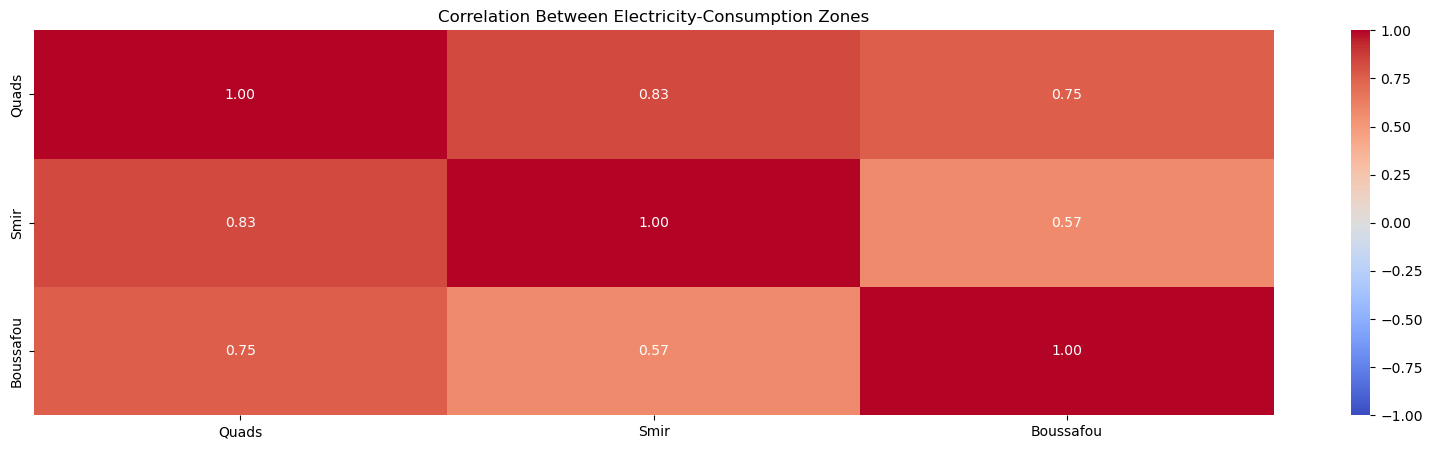

In [104]:
# Create a heatmap showing the correlation between the three zones
sns.heatmap(
    zone_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

# Add a clear title
plt.title("Correlation Between Electricity-Consumption Zones")

# Display the chart
plt.show()

The three electricity-consumption zones were positively correlated, indicating that demand generally rose and fell across the city in the same direction. Quads and Smir had the strongest relationship, with a correlation of 0.83, suggesting very similar demand patterns. Boussafou was less closely aligned with the other zones, particularly Smir, which supports earlier findings that Boussafou behaves differently during seasonal and peak-demand periods.

C:\Users\azimi\AppData\Local\Temp\ipykernel_7048\1949804863.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


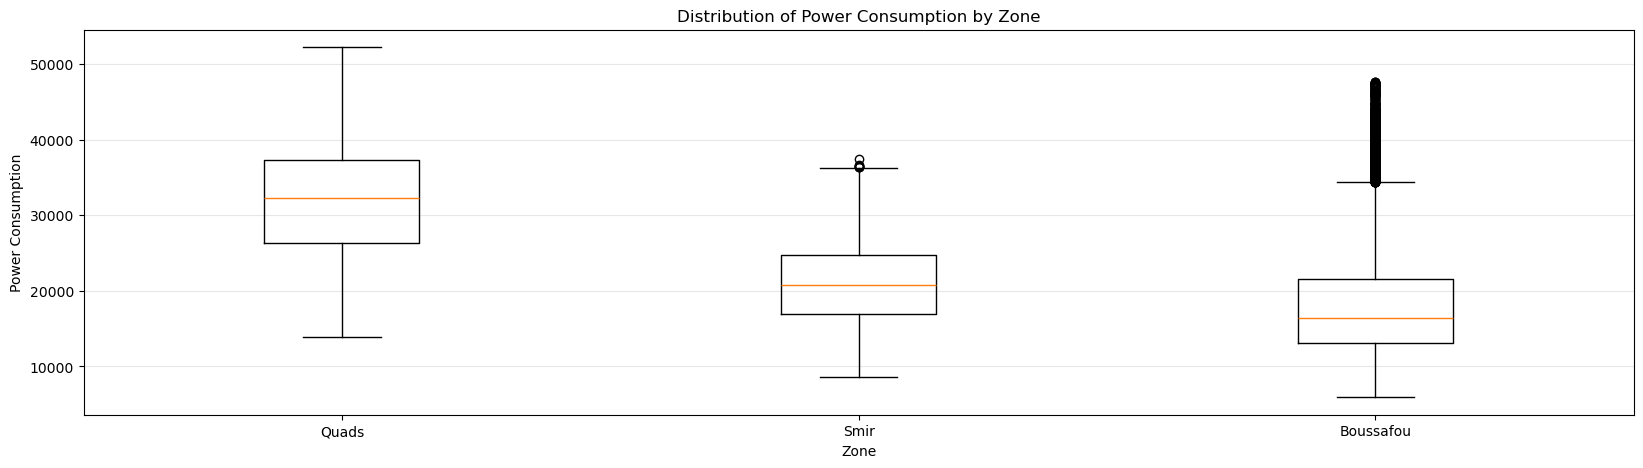

In [105]:
# Create a box plot comparing power consumption across the three zones
plt.boxplot(
    [
        df["quads_power_consumption"],
        df["smir_power_consumption"],
        df["boussafou_power_consumption"]
    ],
    labels=["Quads", "Smir", "Boussafou"]
)

# Add title and axis labels
plt.title("Distribution of Power Consumption by Zone")
plt.xlabel("Zone")
plt.ylabel("Power Consumption")

# Add light gridlines
plt.grid(axis="y", alpha=0.3)

# Display the chart
plt.show()

The box plots show clear differences in the distribution of electricity consumption across the three zones. Quads has the highest median and the highest typical consumption levels. Smir has a lower and comparatively tighter distribution. Boussafou has the lowest median but displays many high-end potential outliers, indicating that although its typical demand is lower, it experiences frequent periods of unusually high consumption.

*Note: These points are statistical outliers according to the box-plot rule, not necessarily errors. In Boussafou’s case, they likely represent genuine high-demand periods.

>Create a 95th-percentile threshold for each zone and check how often two or all three zones are simultaneously above their own thresholds." lets plot the box plots for each zones, side by side?

Why use the 95th percentile?

The 95th percentile is the value above which only the highest 5% of observations fall.

For each zone, we calculate its own 95th-percentile consumption threshold. Any reading above that threshold is treated as a high-demand event for that zone.

We use the 95th percentile because:

it identifies the most unusually high demand periods without focusing only on the single maximum;
it allows each zone to be judged relative to its own normal demand level;
it works well even when the three zones operate on different consumption scales;
it captures enough events to identify patterns, while still limiting the analysis to genuinely high-demand periods.

For example, Quads normally consumes more electricity than Boussafou. Using one shared numerical threshold would unfairly classify many Quads readings as high demand while potentially missing important Boussafou peaks. A separate 95th-percentile threshold solves that problem.

<li>Let us calculate the threshold for each zone, 
<li>flag high-demand events, 
<li>and then count how many zones were above their own 95th percentile at the same timestamp.

In [107]:
# Calculate the 95th-percentile threshold for each zone
zone_95th_percentiles = df[zone_columns].quantile(0.95)

# Display the thresholds
zone_95th_percentiles

quads_power_consumption       44,712.06
smir_power_consumption        30,387.14
boussafou_power_consumption   29,905.71
Name: 0.95, dtype: float64

In [ ]:
"""Create a high-demand flag for each zone:"""

# Flag whether each zone is above its own 95th-percentile threshold
df["quads_high_demand"] = (
    df["quads_power_consumption"]
    > zone_95th_percentiles["quads_power_consumption"]
)

df["smir_high_demand"] = (
    df["smir_power_consumption"]
    > zone_95th_percentiles["smir_power_consumption"]
)

df["boussafou_high_demand"] = (
    df["boussafou_power_consumption"]
    > zone_95th_percentiles["boussafou_power_consumption"]
)

In [ ]:
"""Count how many zones were simultaneously in high demand:"""

# Count the number of zones above their 95th-percentile threshold
df["number_of_zones_high_demand"] = (
    df[
        [
            "quads_high_demand",
            "smir_high_demand",
            "boussafou_high_demand"
        ]
    ]
    .sum(axis=1)
)

# Count how often zero, one, two, or three zones were in high demand
shared_high_demand_counts = (
    df["number_of_zones_high_demand"]
    .value_counts()
    .sort_index()
)

shared_high_demand_counts

number_of_zones_high_demand
0    46579
1     4589
2      471
3      777
Name: count, dtype: int64

High-demand conditions were absent in approximately 88.9% of observations. When high demand did occur, it was most often isolated to one zone, accounting for 4,589 observations. However, all three zones simultaneously exceeded their individual 95th-percentile thresholds on 777 occasions, while exactly two zones did so on 471 occasions. This indicates that unusual demand events can be zone-specific, but meaningful city-wide peak periods also occur.

Among the 5,837 timestamps where at least one zone was in high demand:

<li>about 78.6% involved only one zone;
<li>about 8.1% involved exactly two zones;
<li>about 13.3% involved all three zones.

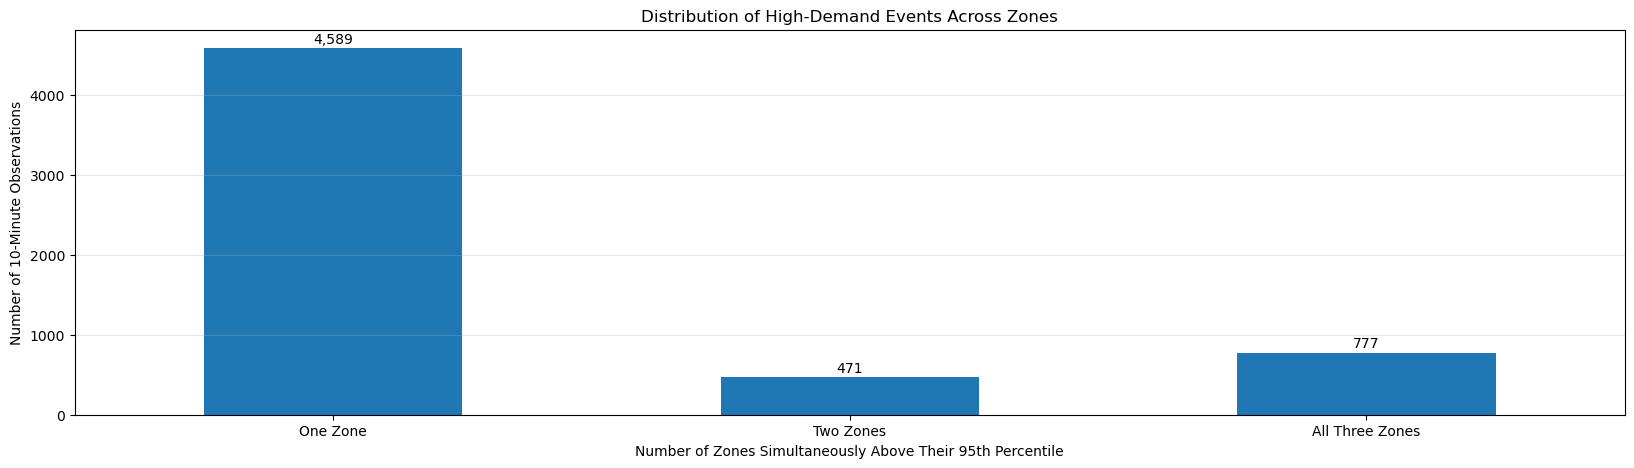

In [110]:
# Keep only observations where at least one zone was in high demand
high_demand_event_counts = shared_high_demand_counts.loc[[1, 2, 3]].copy()

# Replace the numeric index with readable category labels
high_demand_event_counts.index = [
    "One Zone",
    "Two Zones",
    "All Three Zones"
]

# Create a bar chart
high_demand_event_counts.plot(
    kind="bar"
)

# Add a clear title and axis labels
plt.title("Distribution of High-Demand Events Across Zones")
plt.xlabel("Number of Zones Simultaneously Above Their 95th Percentile")
plt.ylabel("Number of 10-Minute Observations")

# Keep category labels horizontal
plt.xticks(rotation=0)

# Add count labels above each bar
for index, value in enumerate(high_demand_event_counts):
    plt.text(
        index,
        value + 60,
        f"{value:,}",
        ha="center"
    )

# Add light horizontal gridlines
plt.grid(axis="y", alpha=0.3)

# Display the chart
plt.show()

In [111]:
# Create a function to label the exact high-demand combination
def label_high_demand_combination(row):

    # Check for all three zones
    if (
        row["quads_high_demand"]
        and row["smir_high_demand"]
        and row["boussafou_high_demand"]
    ):
        return "Quads + Smir + Boussafou"

    # Check for two-zone combinations
    elif row["quads_high_demand"] and row["smir_high_demand"]:
        return "Quads + Smir"

    elif row["quads_high_demand"] and row["boussafou_high_demand"]:
        return "Quads + Boussafou"

    elif row["smir_high_demand"] and row["boussafou_high_demand"]:
        return "Smir + Boussafou"

    # Check for isolated one-zone events
    elif row["quads_high_demand"]:
        return "Quads Only"

    elif row["smir_high_demand"]:
        return "Smir Only"

    elif row["boussafou_high_demand"]:
        return "Boussafou Only"

    # No zone above its threshold
    else:
        return "No High Demand"


# Apply the function to each row
df["high_demand_combination"] = df.apply(
    label_high_demand_combination,
    axis=1
)

# Count each high-demand combination
high_demand_combination_counts = (
    df["high_demand_combination"]
    .value_counts()
    .drop("No High Demand")
    .sort_values(ascending=False)
)

high_demand_combination_counts

high_demand_combination
Smir Only                   1650
Quads Only                  1538
Boussafou Only              1401
Quads + Smir + Boussafou     777
Quads + Boussafou            278
Smir + Boussafou             165
Quads + Smir                  28
Name: count, dtype: int64

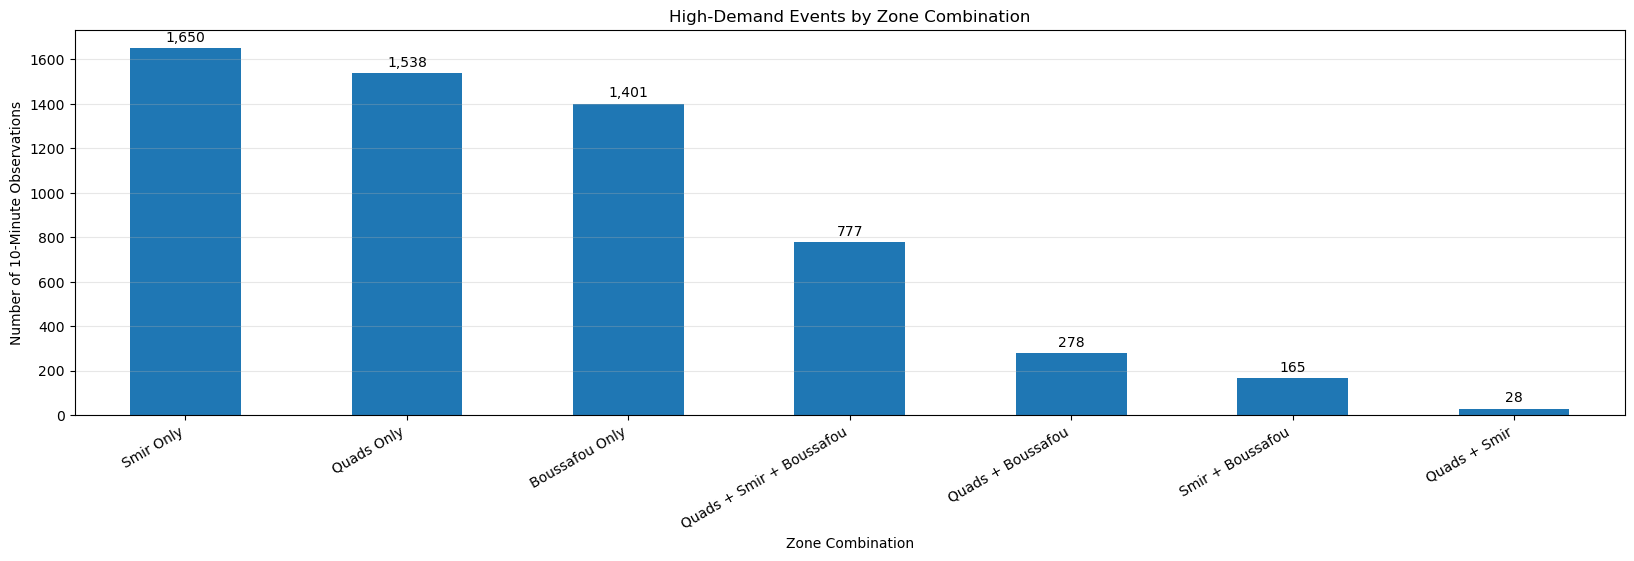

In [112]:
# Create a bar chart of the exact high-demand combinations
high_demand_combination_counts.plot(
    kind="bar"
)

# Add title and axis labels
plt.title("High-Demand Events by Zone Combination")
plt.xlabel("Zone Combination")
plt.ylabel("Number of 10-Minute Observations")

# Rotate labels for readability
plt.xticks(rotation=30, ha="right")

# Add value labels above each bar
for index, value in enumerate(high_demand_combination_counts):
    plt.text(
        index,
        value + 30,
        f"{value:,}",
        ha="center"
    )

# Add light horizontal gridlines
plt.grid(axis="y", alpha=0.3)

# Display the chart
plt.show()

>Most high-demand events were isolated to a single zone, with Smir-only events occurring most often. However, all three zones exceeded their individual 95th-percentile thresholds simultaneously on 777 occasions, indicating a meaningful number of city-wide high-demand periods. Among two-zone combinations, Quads and Boussafou were most often elevated together, while Quads and Smir rarely experienced high demand without Boussafou also being involved.

In [113]:
# Keep only observations where all three zones were in high demand
all_three_high_demand = df[
    df["high_demand_combination"] == "Quads + Smir + Boussafou"
].copy()

# Count the number of 10-minute high-demand observations by date
all_three_daily_counts = (
    all_three_high_demand
    .groupby("date")
    .size()
    .sort_values(ascending=False)
)

# Display the dates with the most all-three-zone high-demand observations
all_three_daily_counts.head(10)

date
2017-08-07    23
2017-08-08    22
2017-08-17    22
2017-07-24    21
2017-07-31    21
2017-08-18    21
2017-08-16    21
2017-08-05    21
2017-07-29    21
2017-07-28    21
dtype: int64

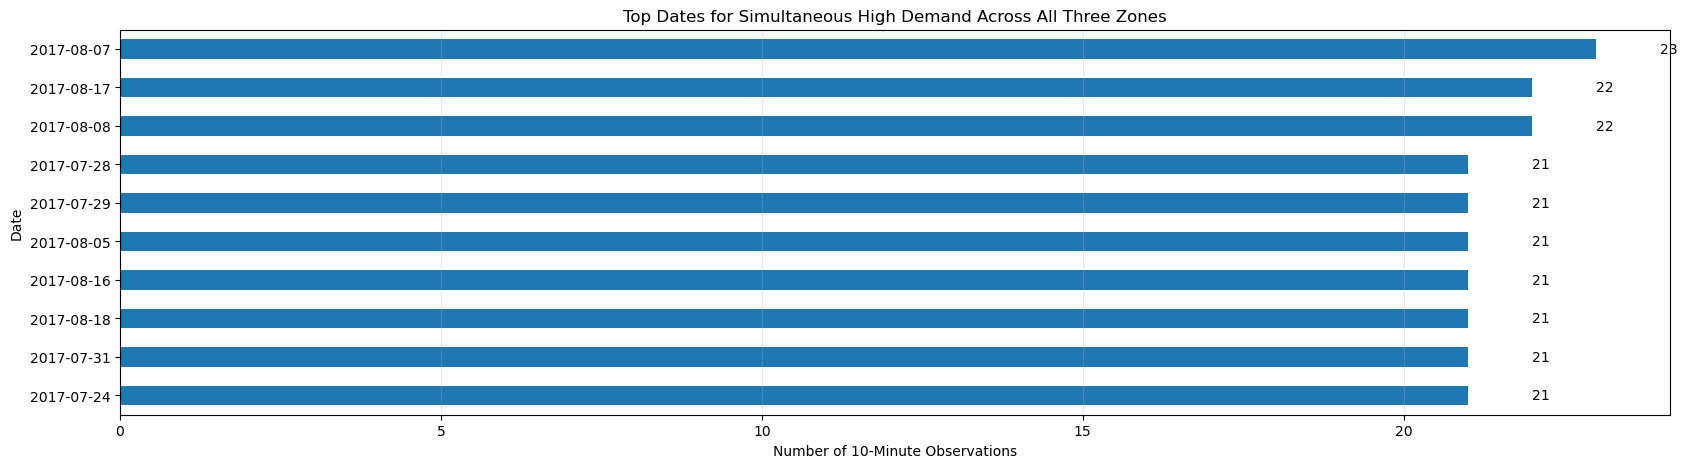

In [114]:
# Select the 10 dates with the most shared high-demand observations
top_shared_peak_dates = all_three_daily_counts.head(10).sort_values()

# Create a horizontal bar chart
top_shared_peak_dates.plot(
    kind="barh"
)

# Add title and axis labels
plt.title("Top Dates for Simultaneous High Demand Across All Three Zones")
plt.xlabel("Number of 10-Minute Observations")
plt.ylabel("Date")

# Add value labels
for index, value in enumerate(top_shared_peak_dates):
    plt.text(
        value + 1,
        index,
        f"{value}",
        va="center"
    )

# Add light gridlines
plt.grid(axis="x", alpha=0.3)

# Display the chart
plt.show()

># 10. Ramadan Electricity-Consumption Analysis

For Morocco in 2017, we will define:

Ramadan: 27 May through 25 June
Pre-Ramadan comparison: the 30 days immediately before Ramadan
Post-Ramadan comparison: the 30 days immediately after Ramadan

This gives us three similarly sized periods for a fair initial comparison.

Step 1: Create the Ramadan comparison periods

In [118]:
# Define the Ramadan dates for Morocco in 2017
ramadan_start = pd.Timestamp("2017-05-27")
ramadan_end = pd.Timestamp("2017-06-25 23:59:59")

# Define the 30-day period immediately before Ramadan
pre_ramadan_start = pd.Timestamp("2017-04-27")
pre_ramadan_end = pd.Timestamp("2017-05-26 23:59:59")

# Define the 30-day period immediately after Ramadan
post_ramadan_start = pd.Timestamp("2017-06-26")
post_ramadan_end = pd.Timestamp("2017-07-25 23:59:59")

Now create a period label:

In [119]:
# Create a function to label each observation
# as Pre-Ramadan, Ramadan, Post-Ramadan or Outside Comparison Period
def assign_ramadan_period(datetime_value):

    # Observations during the 30 days before Ramadan
    if pre_ramadan_start <= datetime_value <= pre_ramadan_end:
        return "Pre-Ramadan"

    # Observations during Ramadan
    elif ramadan_start <= datetime_value <= ramadan_end:
        return "Ramadan"

    # Observations during the 30 days after Ramadan
    elif post_ramadan_start <= datetime_value <= post_ramadan_end:
        return "Post-Ramadan"

    # All remaining observations
    else:
        return "Outside Comparison Period"


# Apply the function to the datetime column
df["ramadan_period"] = df["datetime"].apply(
    assign_ramadan_period
)

# Count the number of observations in each period
df["ramadan_period"].value_counts()

ramadan_period
Outside Comparison Period    39456
Pre-Ramadan                   4320
Ramadan                       4320
Post-Ramadan                  4320
Name: count, dtype: int64

Step 2: Preview the labelled observations

In [120]:
# Display a sample from the three comparison periods
df.loc[
    df["ramadan_period"] != "Outside Comparison Period",
    [
        "datetime",
        "ramadan_period",
        "hour",
        "total_power_consumption"
    ]
].head()

,datetime,ramadan_period,hour,total_power_consumption
16704,2017-04-27 00:00:00,Pre-Ramadan,0,"64,035.87"
16705,2017-04-27 00:10:00,Pre-Ramadan,0,"62,074.43"
16706,2017-04-27 00:20:00,Pre-Ramadan,0,"61,012.11"
16707,2017-04-27 00:30:00,Pre-Ramadan,0,"59,817.47"
16708,2017-04-27 00:40:00,Pre-Ramadan,0,"59,204.83"


Now calculate the average hourly demand profile for the three periods:

In [121]:
# Keep only the three Ramadan comparison periods
ramadan_comparison_df = df[
    df["ramadan_period"] != "Outside Comparison Period"
].copy()

# Define the correct display order
ramadan_period_order = [
    "Pre-Ramadan",
    "Ramadan",
    "Post-Ramadan"
]

# Calculate average total power consumption by hour and period
ramadan_hourly_profile = (
    ramadan_comparison_df
    .groupby(
        [
            "ramadan_period",
            "hour"
        ]
    )["total_power_consumption"]
    .mean()
    .reset_index()
)

# Convert the period column into an ordered category
ramadan_hourly_profile["ramadan_period"] = pd.Categorical(
    ramadan_hourly_profile["ramadan_period"],
    categories=ramadan_period_order,
    ordered=True
)

# Sort the results by period and hour
ramadan_hourly_profile = ramadan_hourly_profile.sort_values(
    by=[
        "ramadan_period",
        "hour"
    ]
)

# Preview the hourly profiles
ramadan_hourly_profile.head(10)

,ramadan_period,hour,total_power_consumption
24,Pre-Ramadan,0,"64,641.08"
25,Pre-Ramadan,1,"58,219.40"
26,Pre-Ramadan,2,"55,217.71"
27,Pre-Ramadan,3,"55,326.92"
28,Pre-Ramadan,4,"53,672.35"
29,Pre-Ramadan,5,"45,635.04"
30,Pre-Ramadan,6,"47,556.24"
31,Pre-Ramadan,7,"52,229.32"
32,Pre-Ramadan,8,"58,798.41"
33,Pre-Ramadan,9,"65,603.83"


Identify the peak and minimum hour for each period:

In [122]:
# Create an empty list to store hourly extremes
ramadan_hourly_extremes = []

# Check each comparison period separately
for period_name in ramadan_period_order:

    # Filter the hourly profile for the current period
    period_data = ramadan_hourly_profile[
        ramadan_hourly_profile["ramadan_period"] == period_name
    ]

    # Find the rows containing the highest and lowest hourly averages
    peak_row = period_data.loc[
        period_data["total_power_consumption"].idxmax()
    ]

    minimum_row = period_data.loc[
        period_data["total_power_consumption"].idxmin()
    ]

    # Store the results
    ramadan_hourly_extremes.append({
        "period": period_name,
        "peak_hour": int(peak_row["hour"]),
        "peak_average_consumption": peak_row["total_power_consumption"],
        "minimum_hour": int(minimum_row["hour"]),
        "minimum_average_consumption": minimum_row["total_power_consumption"]
    })

# Convert the results into a dataframe
ramadan_hourly_extremes = pd.DataFrame(
    ramadan_hourly_extremes
)

ramadan_hourly_extremes

,period,peak_hour,peak_average_consumption,minimum_hour,minimum_average_consumption
0,Pre-Ramadan,20,"98,133.03",5,"45,635.04"
1,Ramadan,20,"100,885.77",6,"47,095.92"
2,Post-Ramadan,20,"116,100.05",5,"55,032.90"


Ramadan did not change the city’s main peak hour, which remained at 8:00 PM. However, the average peak demand during Ramadan was slightly higher than in the 30 days before Ramadan. The much higher post-Ramadan peak should not automatically be attributed to Ramadan ending, because the post-period extends into late July, when summer demand was already rising sharply.

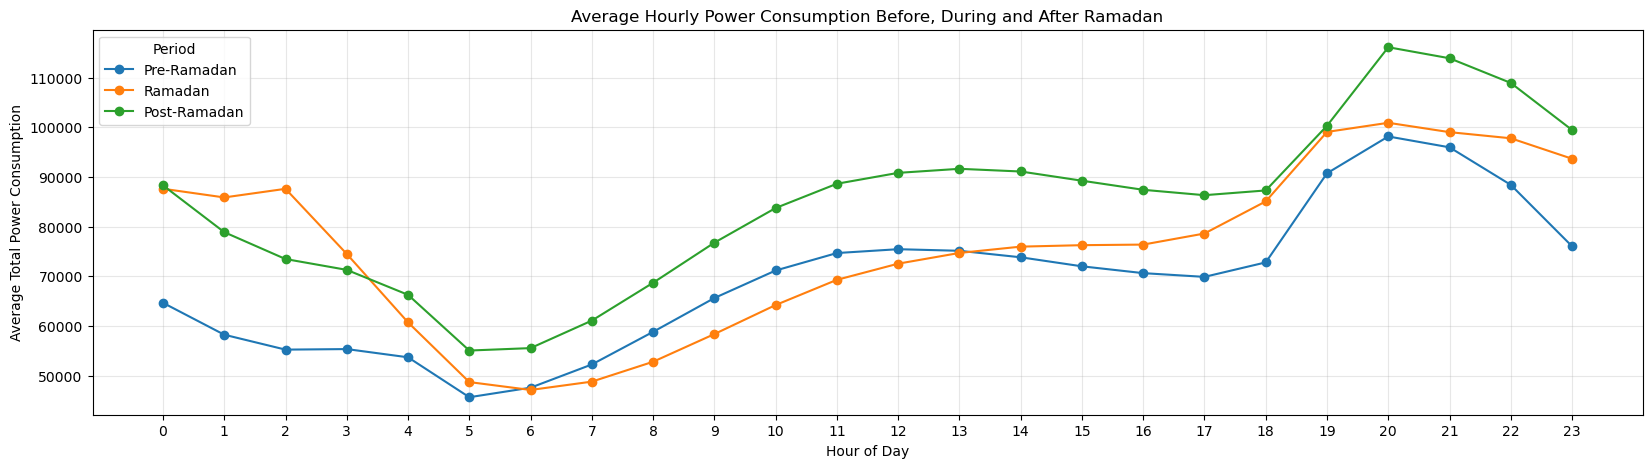

In [123]:
# Plot the hourly demand profile for each comparison period
for period_name in ramadan_period_order:

    # Filter the hourly profile for one period
    period_data = ramadan_hourly_profile[
        ramadan_hourly_profile["ramadan_period"] == period_name
    ]

    # Plot the average hourly total consumption
    plt.plot(
        period_data["hour"],
        period_data["total_power_consumption"],
        marker="o",
        label=period_name
    )

# Add title and axis labels
plt.title("Average Hourly Power Consumption Before, During and After Ramadan")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Power Consumption")

# Display every hour from 0 to 23
plt.xticks(range(24))

# Add gridlines and legend
plt.grid(alpha=0.3)
plt.legend(title="Period")

# Display the chart
plt.show()

The Ramadan curve shows a distinct change in the shape of the daily demand pattern, not merely a change in average consumption:

<li>Ramadan demand is much higher from midnight through roughly 4:00 AM than during the pre-Ramadan period.
<li>The minimum shifts from 5:00 AM before Ramadan to 6:00 AM during Ramadan.
<li>Demand stays lower than the post-Ramadan period through much of the day.
<li>The evening rise begins sharply around 6:00–7:00 PM.
<li>All three periods peak at 8:00 PM, but Ramadan demand remains elevated later into the night.

The hourly demand profile changed noticeably during Ramadan. Compared with the 30 days before Ramadan, electricity consumption was substantially higher during the late-night and early-morning hours, consistent with altered household activity and meal preparation patterns. The daily minimum shifted from 5:00 AM to 6:00 AM, while the main evening peak remained at 8:00 PM. Ramadan therefore changed the timing and shape of electricity demand even though the principal peak hour remained unchanged.

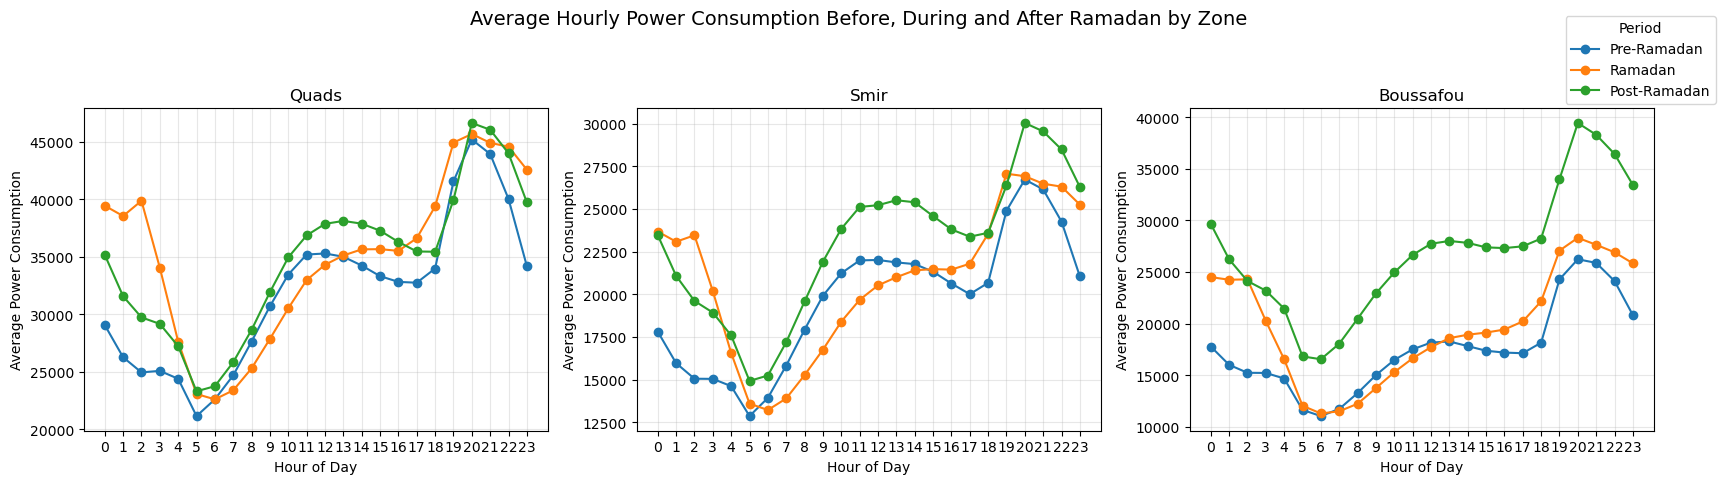

In [124]:
# Define the three zone columns and readable titles
ramadan_zone_columns = {
    "Quads": "quads_power_consumption",
    "Smir": "smir_power_consumption",
    "Boussafou": "boussafou_power_consumption"
}

# Calculate average hourly consumption by Ramadan period for each zone
ramadan_zone_hourly_profile = (
    ramadan_comparison_df
    .groupby(["ramadan_period", "hour"])[
        [
            "quads_power_consumption",
            "smir_power_consumption",
            "boussafou_power_consumption"
        ]
    ]
    .mean()
    .reset_index()
)

# Create a 1 x 3 grid of charts
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
    sharex=True,
    sharey=False
)

# Loop through each zone
for axis, (zone_name, zone_column) in zip(axes, ramadan_zone_columns.items()):

    # Plot each Ramadan comparison period
    for period_name in ramadan_period_order:

        # Filter data for one period
        period_data = ramadan_zone_hourly_profile[
            ramadan_zone_hourly_profile["ramadan_period"] == period_name
        ]

        # Plot the hourly profile
        axis.plot(
            period_data["hour"],
            period_data[zone_column],
            marker="o",
            label=period_name
        )

    # Add chart title and labels
    axis.set_title(zone_name)
    axis.set_xlabel("Hour of Day")
    axis.set_ylabel("Average Power Consumption")
    axis.set_xticks(range(24))
    axis.grid(alpha=0.3)

# Add one overall title
fig.suptitle(
    "Average Hourly Power Consumption Before, During and After Ramadan by Zone",
    fontsize=14
)

# Add one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Period",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98)
)

# Adjust spacing
plt.tight_layout(rect=[0.02, 0.02, 0.95, 0.92])

# Display the chart
plt.show()

The three-zone breakdown shows that the Ramadan effect was not identical across the city.

<li>Quads: Ramadan demand is dramatically higher after midnight through about 4:00 AM, then remains above pre-Ramadan demand through much of the evening.
<li>Smir: The same late-night Ramadan increase appears, but the difference is smaller. The post-Ramadan period dominates much of the daytime and late evening.
<li>Boussafou: Ramadan raises demand overnight and in the evening, but the post-Ramadan summer effect is especially strong from late morning through the evening.

The Ramadan effect differed across the three zones. Quads showed the clearest increase in late-night and early-morning consumption during Ramadan, while Smir displayed a similar but smaller shift. Boussafou also recorded higher overnight Ramadan demand, although its post-Ramadan profile was much higher during the daytime and evening because of the strengthening summer-demand pattern. Overall, Ramadan appears to have altered the timing of electricity use most clearly during the overnight period rather than changing the main 8:00 PM peak hour.

Boussafou’s pronounced daytime, summer and peak-period demand patterns may indicate a different customer or land-use mix from the other zones, potentially including greater industrial or high-load commercial activity. However, this interpretation cannot be confirmed from the dataset alone and would require external land-use or utility information.

># 11. Load Forecasting

For the core version, we will forecast:

Total city power consumption 10 minutes ahead

We will compare only two approaches:

<li>Naive persistence forecast — assumes the next reading will equal the current reading.
<li>Linear regression forecast — uses recent demand, time and weather information.


Most importantly, we will split the data chronologically, not randomly, because future observations must not be used to predict the past.

In [ ]:
# Create the target column:
# the total power consumption one 10-minute interval into the future
df["target_next_10min"] = (
    df["total_power_consumption"]
    .shift(-1)
)

# Preview the current and next 10-minute consumption values
df[
    [
        "datetime",
        "total_power_consumption",
        "target_next_10min"
    ]
].tail()

"""Why use .shift(-1)?
    moves the values upward by one row.
    Therefore: the current row contains the information available now;
                target_next_10min contains the consumption reading from the next timestamp."""

,datetime,total_power_consumption,target_next_10min
52411,2017-12-30 23:10:00,"72,798.09","70,983.81"
52412,2017-12-30 23:20:00,"70,983.81","68,675.05"
52413,2017-12-30 23:30:00,"68,675.05","67,163.02"
52414,2017-12-30 23:40:00,"67,163.02","65,750.54"
52415,2017-12-30 23:50:00,"65,750.54",NaN


In [126]:
# Count missing values in the forecasting target
df["target_next_10min"].isna().sum()

1

Now let's build the naive persistence forecast first. This gives us a baseline that any machine-learning model must beat.

In [127]:
# Remove the final row because its forecasting target is missing
forecast_df = df.dropna(subset=["target_next_10min"]).copy()

# Create the naive forecast:
# assume the next 10-minute value will equal the current value
forecast_df["naive_prediction"] = (
    forecast_df["total_power_consumption"]
)

# Preview the actual next value and the naive prediction
forecast_df[
    [
        "datetime",
        "total_power_consumption",
        "target_next_10min",
        "naive_prediction"
    ]
].head()

,datetime,total_power_consumption,target_next_10min,naive_prediction
0,2017-01-01 00:00:00,"70,425.54","69,320.84","70,425.54"
1,2017-01-01 00:10:00,"69,320.84","67,803.22","69,320.84"
2,2017-01-01 00:20:00,"67,803.22","65,489.23","67,803.22"
3,2017-01-01 00:30:00,"65,489.23","63,650.45","65,489.23"
4,2017-01-01 00:40:00,"63,650.45","62,171.34","63,650.45"


Then evaluate it with three metrics:

In [ ]:
# Import the forecasting evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate the naive-model evaluation metrics
naive_mae = mean_absolute_error(
    forecast_df["target_next_10min"],
    forecast_df["naive_prediction"]
)

naive_rmse = mean_squared_error(
    forecast_df["target_next_10min"],
    forecast_df["naive_prediction"]
) ** 0.5

naive_r2 = r2_score(
    forecast_df["target_next_10min"],
    forecast_df["naive_prediction"]
)

# Display the results
pd.Series({
    "MAE": naive_mae,
    "RMSE": naive_rmse,
    "R²": naive_r2
})

"""What the metrics mean
    MAE: the average absolute prediction error.
    RMSE: similar to MAE, but gives more weight to large errors.
    R²: how much of the variation in the next reading is explained by the forecast. Values closer to 1 are better."""

MAE      899.72
RMSE   1,321.67
R²         0.99
dtype: float64

The naive persistence model produced a mean absolute error of approximately 900 and an R² of 0.99. This indicates that the next 10-minute demand value is highly similar to the current reading. Because the baseline is already very strong, any machine-learning model should be evaluated against it on the same unseen test period.

* Note-We should not compare this full-dataset baseline directly with a model evaluated only on a test set. Next, we will create the chronological split and calculate the naive and regression results on that same test period.

In [129]:
# Choose 80% of the observations for training
split_index = int(len(forecast_df) * 0.80)

# Split the dataframe chronologically
train_df = forecast_df.iloc[:split_index].copy()
test_df = forecast_df.iloc[split_index:].copy()

# Display the number of observations in each set
print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

# Display the date range of each set
print(
    "Training period:",
    train_df["datetime"].min(),
    "to",
    train_df["datetime"].max()
)

print(
    "Testing period:",
    test_df["datetime"].min(),
    "to",
    test_df["datetime"].max()
)

Training observations: 41932
Testing observations: 10483
Training period: 2017-01-01 00:00:00 to 2017-10-19 04:30:00
Testing period: 2017-10-19 04:40:00 to 2017-12-30 23:40:00


In [130]:
# Calculate the naive forecast metrics on the test period
naive_test_mae = mean_absolute_error(
    test_df["target_next_10min"],
    test_df["naive_prediction"]
)

naive_test_rmse = mean_squared_error(
    test_df["target_next_10min"],
    test_df["naive_prediction"]
) ** 0.5

naive_test_r2 = r2_score(
    test_df["target_next_10min"],
    test_df["naive_prediction"]
)

# Display the test-period baseline results
naive_test_results = pd.Series({
    "MAE": naive_test_mae,
    "RMSE": naive_test_rmse,
    "R²": naive_test_r2
})

naive_test_results

MAE      787.59
RMSE   1,187.04
R²         0.99
dtype: float64

Now lets build the simplest linear-regression model using only the current total consumption to predict the next 10-minute value.

In [131]:
# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

# Select the current total consumption as the only feature
feature_columns_model_1 = [
    "total_power_consumption"
]

# Create the training features and target
X_train_1 = train_df[feature_columns_model_1]
y_train = train_df["target_next_10min"]

# Create the testing features and target
X_test_1 = test_df[feature_columns_model_1]
y_test = test_df["target_next_10min"]

# Create the Linear Regression model
linear_model_1 = LinearRegression()

# Train the model using the training data
linear_model_1.fit(
    X_train_1,
    y_train
)

# Predict the next 10-minute consumption values
linear_predictions_1 = linear_model_1.predict(
    X_test_1
)

# Calculate evaluation metrics
linear_1_mae = mean_absolute_error(
    y_test,
    linear_predictions_1
)

linear_1_rmse = mean_squared_error(
    y_test,
    linear_predictions_1
) ** 0.5

linear_1_r2 = r2_score(
    y_test,
    linear_predictions_1
)

# Display the model results
linear_1_results = pd.Series({
    "MAE": linear_1_mae,
    "RMSE": linear_1_rmse,
    "R²": linear_1_r2
})

linear_1_results

MAE      786.08
RMSE   1,186.21
R²         0.99
dtype: float64

A linear-regression model using only the current consumption reading performed almost identically to the naive persistence forecast. This indicates that, over a 10-minute horizon, the current demand level already contains nearly all of the predictive information needed for the next observation. The added model complexity produced only a minimal improvement.

>Does adding weather and time-based information improve forecast accuracy?

In [132]:
# Define the expanded feature set
feature_columns_model_2 = [
    "total_power_consumption",
    "temperature",
    "humidity",
    "wind_speed",
    "general_diffuse_flows",
    "diffuse_flows",
    "hour",
    "month",
    "is_weekend"
]

# Create the training and testing feature sets
X_train_2 = train_df[feature_columns_model_2]
X_test_2 = test_df[feature_columns_model_2]

# Create the second Linear Regression model
linear_model_2 = LinearRegression()

# Train the model
linear_model_2.fit(
    X_train_2,
    y_train
)

# Predict the next 10-minute consumption values
linear_predictions_2 = linear_model_2.predict(
    X_test_2
)

# Calculate evaluation metrics
linear_2_mae = mean_absolute_error(
    y_test,
    linear_predictions_2
)

linear_2_rmse = mean_squared_error(
    y_test,
    linear_predictions_2
) ** 0.5

linear_2_r2 = r2_score(
    y_test,
    linear_predictions_2
)

# Display the results
linear_2_results = pd.Series({
    "MAE": linear_2_mae,
    "RMSE": linear_2_rmse,
    "R²": linear_2_r2
})

linear_2_results

MAE      776.53
RMSE   1,179.20
R²         0.99
dtype: float64

The expanded linear-regression model achieved the best forecasting performance, with an MAE of 776.53 and an RMSE of 1,179.20. Adding weather and time-based features improved accuracy compared with both the naive forecast and the single-feature regression model. However, the improvement was relatively small, indicating that the current demand reading already contains most of the information needed to predict consumption 10 minutes ahead.

>Comparison Table

In [133]:
# Create a dataframe comparing all three forecasting approaches
forecast_model_comparison = pd.DataFrame({
    "Model": [
        "Naive Persistence",
        "Linear Regression - Current Demand",
        "Linear Regression - Weather and Time"
    ],
    "MAE": [
        naive_test_mae,
        linear_1_mae,
        linear_2_mae
    ],
    "RMSE": [
        naive_test_rmse,
        linear_1_rmse,
        linear_2_rmse
    ],
    "R²": [
        naive_test_r2,
        linear_1_r2,
        linear_2_r2
    ]
})

# Sort the models from lowest to highest MAE
forecast_model_comparison = forecast_model_comparison.sort_values(
    by="MAE"
).reset_index(drop=True)

forecast_model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression - Weather and Time,776.53,"1,179.20",0.99
1,Linear Regression - Current Demand,786.08,"1,186.21",0.99
2,Naive Persistence,787.59,"1,187.04",0.99


In [134]:
# Display the model comparison with four decimal places
forecast_model_comparison.style.format({
    "MAE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "R²": "{:.4f}"
})

,Model,MAE,RMSE,R²
0,Linear Regression - Weather and Time,776.53,"1,179.20",0.9930
1,Linear Regression - Current Demand,786.08,"1,186.21",0.9929
2,Naive Persistence,787.59,"1,187.04",0.9929


All three forecasting approaches predicted the next 10-minute consumption value with very high accuracy. 

The linear-regression model using current demand, weather and time-based features performed best, achieving an MAE of 776.53, an RMSE of 1,179.20 and an R² of 0.9930. 

However, its improvement over the naive persistence model was modest. This indicates that short-term electricity consumption is highly dependent on the immediately preceding reading, while weather and time variables provide a small additional improvement.

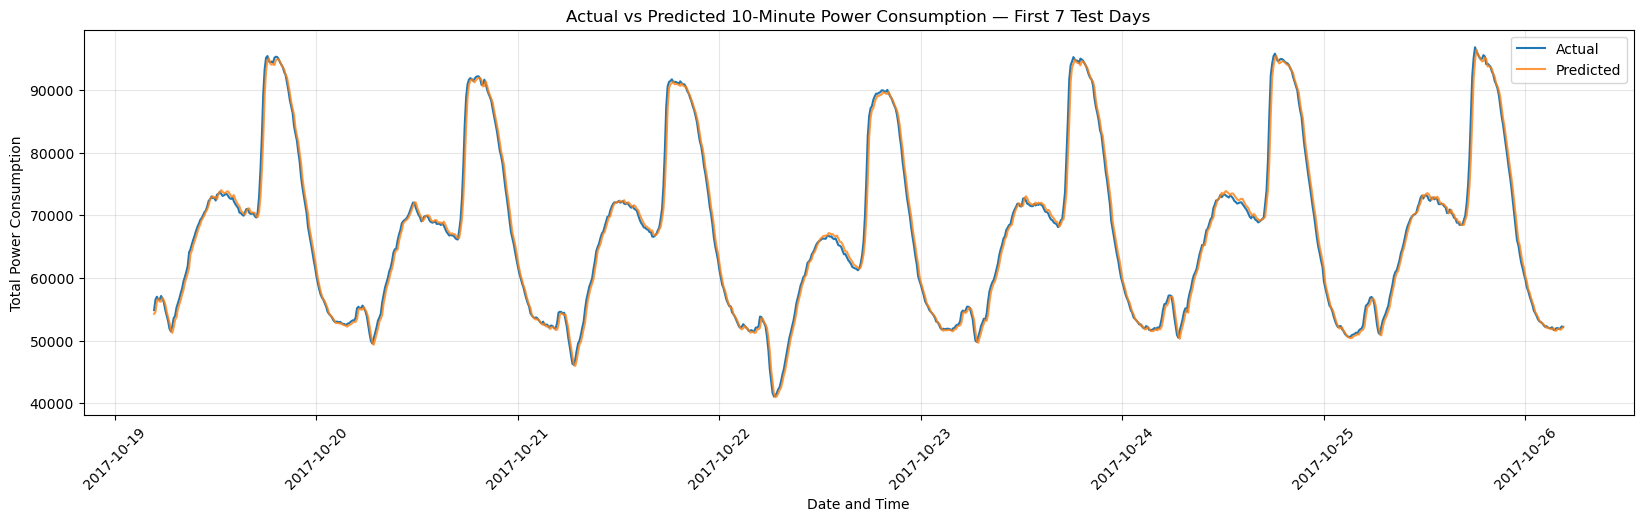

In [135]:
# Create a dataframe containing actual and predicted test values
forecast_results = test_df[
    [
        "datetime",
        "target_next_10min"
    ]
].copy()

# Add predictions from the best-performing model
forecast_results["predicted_next_10min"] = linear_predictions_2

# Select the first seven days of the test period
seven_day_end = (
    forecast_results["datetime"].min()
    + pd.Timedelta(days=7)
)

forecast_plot_data = forecast_results[
    forecast_results["datetime"] < seven_day_end
]

# Plot the actual and predicted consumption values
plt.plot(
    forecast_plot_data["datetime"],
    forecast_plot_data["target_next_10min"],
    label="Actual"
)

plt.plot(
    forecast_plot_data["datetime"],
    forecast_plot_data["predicted_next_10min"],
    label="Predicted",
    alpha=0.8
)

# Add title and axis labels
plt.title("Actual vs Predicted 10-Minute Power Consumption — First 7 Test Days")
plt.xlabel("Date and Time")
plt.ylabel("Total Power Consumption")

# Add legend and gridlines
plt.legend()
plt.grid(alpha=0.3)

# Rotate date labels
plt.xticks(rotation=45)

# Display the chart
plt.show()

The actual and predicted consumption lines closely overlap throughout the first seven days of the unseen test period. The model successfully reproduced the daily demand cycle, including the major peaks and troughs. Small differences remain around some rapid changes, but overall the expanded linear-regression model provides highly accurate 10-minute-ahead forecasts.

ARIMA and LSTM were not included in the initial forecasting scope because the 10-minute-ahead demand series showed very strong short-term persistence. A naive persistence model already achieved an R² of approximately 0.993, and adding weather and time features produced only a modest improvement. Therefore, simple and interpretable models were prioritised before considering more complex time-series or deep-learning approaches.

That does not mean ARIMA or LSTM are useless here. They would be more worthwhile for:

<li>longer forecast horizons, such as 1 hour, 6 hours, or 24 hours ahead;
<li>forecasting an entire future demand curve;
<li>modelling daily and weekly seasonality;
<li>comparing performance during Ramadan or summer peaks;
<li>testing whether nonlinear patterns improve accuracy.

In [136]:
# Check the CSV file size in megabytes
import os

file_size_mb = os.path.getsize(
    "Tetuan City power consumption.csv"
) / (1024 ** 2)

print(f"File size: {file_size_mb:.2f} MB")

File size: 4.03 MB
